# VEST operational space and MHD stability limits (Tier A)

The conference figure set (2026-10-12). VAFT reconstructs equilibria and kinetic profiles as a pipeline, and
the stability codes run on those equilibria. This notebook places every Tier A state on each operating-limit
plane of the literature, one section per limit.

**How to read it.** The method cells come first: which equilibria are used, how they were reconstructed, and
how each stability criterion is computed and marked. They are stated once here and are not repeated on the
figures. Each limit section then shows the same nine figures in the same order:

1. the equilibria alone;
2. the equilibrium quality (the only figure that shows it);
3. ideal MHD stability over all $n$, and 4. its representative discharges in time;
5. the classical tearing drive ($\Delta' > 0$) over all $n$, and 6. its representative discharges;
7. local stability (ballooning / interchange), and 8. its representative discharges;
9. a combined overview (a visualisation convenience, not a physical priority).

**Boundaries.** Each limit is drawn from `vaft.formula.boundaries`, only on its own quantities. The forbidden side
is hatched, the limit's name is written along the line, and the side every limit allows is labelled *Stable*. The
legend says what each line is: `{name} ({fixed inputs}) Unstable (Empirical | Analytical | Numerical)`.

In [ ]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import vaft
from vaft.diagram._op_space import get_projection
from vaft.plot.operational_space import operational_space_population

ATLAS = Path(os.environ.get("VAFT_ATLAS_DIR", "atlas")).expanduser()
plt.rcParams["figure.dpi"] = 72   # the format sets physical inches and points; 72 dpi keeps the notebook small
# the slide format (11 in wide, at most 5.8 in tall, 18 pt type, heavy lines) for the talk
FORMAT, THEME = "slide", "technical"   # 16:9 talk figures (#1572)
print("figure format:", FORMAT, "| theme:", THEME)
print("vaft", vaft.__version__, "| atlas:", ATLAS.name, "| exists:", ATLAS.is_dir())

figure format: slide | theme: technical
vaft 0.7.1 | atlas: atlas | exists: True


## Data

The atlas tables are read from `$VAFT_ATLAS_DIR` (on vestserver `~/runs/campaign/atlas`; elsewhere an rsync of it).
States are keyed by Lane K's State key contract v1 (#1454), `(shot, time_efit_s, efit_lineage)`, and every layer is
joined exactly on that key, with time as integer microseconds, never by index. Each join prints how many states it
matched.

| file | lane | contents |
|---|---|---|
| `lane_v/efit_base.csv` | V (#1456) | the coordinates of every plane, computed by VAFT from the state's own EFIT product |
| `v1/state.csv` | K (#1454) | quality labels and the Thomson match |
| `confinement/table.csv` | D (#1490) | line-averaged $\bar n_e$ along the $z = 0$ chord inside the LCFS from the Thomson profile, and $P_{loss} = P_{OH} - dW/dt$ |
| `stability/atlas_n.csv`, `atlas_surfaces.csv` | N (#1448) | DCON $W_t$ per $n$, RDCON $\Delta'$ per rational surface, local criteria |

In [ ]:
KEY = ["shot", "time_us", "efit_lineage"]
LINEAGE = {"magnetics-only": "magnetics", "electron-kinetic": "electron_kinetic"}   # provisional spellings (T, N)


def _keyed(df):
    df = df.copy()
    df["shot"] = df["shot"].astype(int)
    df["time_us"] = (df["time_efit_s"].astype(float) * 1e6).round().astype(int)
    df["efit_lineage"] = df["efit_lineage"].replace(LINEAGE)
    if "efit_label" in df and "efit_quality" not in df:
        df = df.rename(columns={"efit_label": "efit_quality"})
    return df


def read_layer(*parts):
    path = ATLAS.joinpath(*parts)
    files = sorted(path.glob("*.csv")) if path.is_dir() else ([path] if path.is_file() else [])
    if not files:
        return None, f"not available ({'/'.join(parts)} absent)"
    return pd.concat([_keyed(pd.read_csv(f)) for f in files], ignore_index=True), f"{len(files)} file(s)"


base, base_note = read_layer("lane_v", "efit_base.csv")
kin, kin_note = read_layer("v1", "state.csv")
assert base is not None, "the Lane V base table is required: run workflow/operational_space_atlas/build_efit_base.py"
display(base["base_status"].value_counts().rename("base rows").to_frame())   # nothing is dropped unseen
base = base[base["base_status"] == "valid"]
assert set(base["efit_quality"]) <= {"good", "admissible"}, "only good and admissible slices belong in the atlas"

table = base.copy()
def join(left, right, columns, layer):
    # left join on the state key; report how many states found a row, so a failed join is visible
    right = right[KEY + list(columns)]
    out = left.drop(columns=[c for c in columns if c in left]).merge(right, on=KEY, how="left",
                                                                      validate="one_to_one", indicator=True)
    matched = int((out.pop("_merge") == "both").sum())
    print(f"{layer}: {matched} of {len(left)} states matched; {len(right) - matched} layer rows unused")
    return out


if kin is not None:
    table = join(table, kin, ["r_sum", "r_w", "ts_status"], "kinetic state (K)")
conf, conf_note = read_layer("confinement", "table.csv")
if conf is not None:
    table = join(table, conf, ["n_e_line_avg_m3", "p_loss_W"], "confinement (D)")
    # derived only through VAFT: Hugill coordinates and the registered Greenwald density, no restated coefficient
    from vaft.formula import boundaries as B
    ne19 = table["n_e_line_avg_m3"] / 1e19
    b_geo = table["b0_t"] * table["r_reference_m"] / table["major_radius_geo_m"]
    ok = ne19.notna()
    table["murakami_parameter"] = np.nan
    table.loc[ok, "murakami_parameter"] = B.hugill_coordinates(
        ne19[ok].to_numpy(), table.loc[ok, "major_radius_geo_m"].to_numpy(), b_geo[ok].to_numpy(),
        table.loc[ok, "minor_radius_m"].to_numpy(), table.loc[ok, "area_elongation"].to_numpy(),
        table.loc[ok, "plasma_current_ma"].to_numpy())[0]
    n_gw = B.boundary_value(B.get_boundary("greenwald"), plasma_current=table["plasma_current_ma"].to_numpy(),
                            minor_radius=table["minor_radius_m"].to_numpy())
    table["greenwald_fraction"] = ne19 / n_gw
    table["loss_power"] = table["p_loss_W"] / 1e6
from vaft.formula import boundaries as B
# machine quantities under the boundary registry's names; B_T at R_geo from the field at the reference radius
table["plasma_current"] = table["plasma_current_ma"]
table["minor_radius"] = table["minor_radius_m"]
table["major_radius"] = table["major_radius_geo_m"]
table["toroidal_field"] = table["b0_t"] * table["r_reference_m"] / table["major_radius_geo_m"]
table["aspect_ratio"] = table["major_radius"] / table["minor_radius"]
# Freidberg's kink safety factor, Eq. (13.160) (not kink_safety_factor, #1524)
table["kink_safety_factor_elliptic"] = B.kink_coordinates(table["minor_radius"], table["major_radius"],
                                                          table["toroidal_field"], table["elongation"],
                                                          table["plasma_current"])
if "n_e_line_avg_m3" in table:
    table["line_average_density"] = table["n_e_line_avg_m3"] / 1e20   # the Martin/Takizuka unit
table.attrs["units"] = {"normalized_beta": "% m T/MA", "normalized_current": "MA m^-1 T^-1", "toroidal_beta": "%",
                        "murakami_parameter": "1e19 m^-2 T^-1", "loss_power": "MW", "plasma_current": "MA",
                        "minor_radius": "m", "major_radius": "m", "toroidal_field": "T", "plasma_surface_area": "m^2",
                        "line_average_density": "1e20 m^-3"}

layers = {"EFIT base (V)": base_note, "kinetic state (K)": kin_note,
          "confinement (D)": conf_note if conf is not None else "not available"}
for name, parts in {"stability (N)": ("stability", "atlas_n.csv"), "transport (T)": ("transport", "radial_summary.csv")}.items():
    layers[name] = read_layer(*parts)[1]
display(pd.Series(layers, name="layer").to_frame())
counts = table.groupby(["efit_lineage", "efit_quality"]).size().rename("states")
display(counts.to_frame())
print(f"{len(table)} states: {counts.get(('magnetics', 'good'), 0)} good + "
      f"{counts.get(('magnetics', 'admissible'), 0)} admissible magnetics slices")

             base rows
base_status           
valid              150

kinetic state (K): 150 of 150 states matched; 0 layer rows unused
confinement (D): 133 of 150 states matched; 0 layer rows unused


                       layer
EFIT base (V)      1 file(s)
kinetic state (K)  1 file(s)
confinement (D)    1 file(s)
stability (N)      1 file(s)
transport (T)      1 file(s)

                               states
efit_lineage     efit_quality        
electron_kinetic admissible        16
                 good               1
magnetics        admissible       115
                 good              18

150 states: 18 good + 115 admissible magnetics slices


## Method 1: which equilibria (equilibrium quality)

The population is the #1331 Tier A campaign: shots whose magnetics are as good as the reference shot 39915
(at most 4 condemned probes, at least 19 usable outboard probes) and that have Thomson scattering. Every EFIT
slice was graded by `workflow/efit_uncertainty_calibration/criteria.py` (criteria version 2):

- **admissible** (a veto): converged; pressure positive everywhere; $\beta_p > 0$ and $W > 0$; $q_{95} \ge 2$; the
  reconstructed over measured plasma current in $[0.3,\ 1 + 2\sigma_{I_p}/|I_p|]$. A slice that fails is *not a
  reconstruction*, whatever its $\chi^2$, and is not in this notebook.
- **good** = admissible, *and* the measurement criterion passes (probe and flux-loop reduced $\chi^2$ in
  $[0.5, 2]$, single-channel $|z| \le 2$ for $I_p$ and the diamagnetic flux), *and* neither the virial check
  (the reconstruction's $\beta_p$ against the `pair_13` virial closure, within a factor 2) nor the Grad–Shafranov
  residual ($\le 5\,\%$) fails.
- Thomson consistency ($p_e \le p \le 2p_e$) is reported but never decides `good`: it is the one independent check.

Only `good` and `admissible` slices are used. Quality is shown once per section (figure 2) and nowhere else: the
stability figures treat every state the same.

## Method 2: how the equilibria were reconstructed

- **`magnetics`**: magnetics-only EFIT (probes, flux loops, Rogowski, diamagnetic flux) with the #891 working
  setting: basis (2,1), calibrated $\sigma$, $\psi$-only exit. The pressure profile is constrained only through
  $\beta_p$ and the diamagnetic flux.
- **`electron_kinetic`**: the same EFIT with the Thomson electron pressure as an additional pressure constraint
  ($T_i = T_e$ assumed for the ions). It exists only at the Thomson times.

The two lineages are separate equilibria of the same discharge at the same time, so both appear as separate
states. Figure 2 of each section separates them by colour.

## Method 3: ideal MHD stability (DCON)

- **Criterion (energy principle):** the sign of DCON's least-stable normalised total energy $W_t$ for each toroidal
  mode number $n$, with the full plasma edge: $W_t > 0$ stable, $W_t \le 0$ unstable, however small. No magnitude
  band is applied.
- **Coverage:** $n = 1$–$6$ when Lane N's atlas v2 is present; until then the $n$ the atlas holds (printed below).
- **Resolution check:** DCON ran at radial resolution mpsi 256 and 512. A verdict counts only when both give the
  same sign.
- **Marking (all $n$):** the colour is the **lowest unstable $n$**. Walking up from $n = 1$: the first $n$ that is
  unstable at both resolutions gives the class; a state stays *Stable* only if every $n$ is stable at both; a state
  is **left out** when its sign changes with resolution at an $n$ below any robustly unstable one, because then its
  lowest unstable $n$ is not known.
- The truncated-edge runs (edge cut at the $dW$ edge peak) show whether an instability depends on the edge region; they
  are not equated with peeling or kink modes (#1607), and are used in the
  interpretation only.

## Method 4: classical tearing drive (RDCON $\Delta' > 0$)

- **Criterion (classical tearing drive):** RDCON's outer-region $\Delta' > 0$ at **any** rational surface, the first
  and last included, for $n = 1, 2$. $\Delta' > 0$ means the ideal outer region supplies free energy to a tearing
  layer; whether a tearing mode actually grows depends on the inner layer, which is not modelled (#939).
- **Resolution check:** per state, the verdict "$\Delta' > 0$ somewhere" must be the same at mpsi 256 and 512.
- **Marking:** as for the ideal criterion: the lowest $n$ whose verdict is robustly positive; *Stable* when every $n$
  is robustly $\Delta' \le 0$ everywhere; left out when the verdict at a lower $n$ depends on resolution.
- STRIDE solves the same outer problem independently; it is quoted in the text as a cross-check only.
- **This is an outer-region tearing-drive criterion, not a matched tearing-mode stability verdict** (#1607): the figures
  call it the classical tearing drive, and a state without a positive $\Delta'$ is shown as "no tearing drive", not as stable.

## Method 5: local stability (ballooning and interchange)

Evaluated by DCON on each flux surface of the equilibrium (independent of $n$):

- **Ballooning / interchange unstable:** the high-$n$ ballooning criterion fails ($C_A < 0$ somewhere) *or* the
  Mercier criterion fails ($D_I > 0$ somewhere, ideal interchange).
- **Resistive interchange only:** neither of those, but the Glasser–Greene–Johnson criterion fails ($D_R > 0$
  somewhere). It is kept as its own class because it is far more common and is a weaker, resistive instability.
- **Stable:** none of the three.

These criteria have no second-resolution run, so no state is left out here.

## Method 6: combined overview (a visualisation convenience)

This is not a physical priority between instabilities (#1607): it only summarises the separate verdicts in one figure.
One class per state, in display order: **ideal** (lowest unstable $n$) first, then **classical tearing drive** (lowest $n$), then
**ballooning / interchange**, then **resistive interchange only**, else **Stable**. Walking down that list, the first
robustly unstable criterion gives the class; a state whose verdict is unresolved at a higher-priority criterion is
left out, because a higher-priority instability cannot be excluded for it.

In [ ]:
IDEAL_COLORS = {"Stable": "#8fd18f", "Ideal n=1 unstable": "#d7263d", "Ideal n=2 unstable": "#9e1a5a",
                "Ideal n=3 unstable": "#6a1b9a", "Ideal n=4 unstable": "#4a3aa7", "Ideal n=5 unstable": "#2a5fa8",
                "Ideal n=6 unstable": "#2a78d6"}
NO_DRIVE = "No tearing drive (Δ′ ≤ 0)"
RESISTIVE_COLORS = {NO_DRIVE: "#8fd18f", "Tearing drive n=1 (Δ′ > 0)": "#f28e2b", "Tearing drive n=2 (Δ′ > 0)": "#e8c547"}
LOCAL_COLORS = {"Stable": "#8fd18f", "Ballooning/interchange unstable": "#1f5fa8",
                "Resistive interchange only ($D_R > 0$)": "#9ecae1"}
COMBINED_COLORS = {**IDEAL_COLORS, **RESISTIVE_COLORS, **LOCAL_COLORS}


def walk(per_n, ns, label, unstable_word="unstable", stable_word="Stable"):
    # per_n[n] in {"unstable", "stable", None (unresolved or missing)}: the lowest robustly unstable n, Stable, or None
    for n in ns:
        v = per_n.get(n)
        if not isinstance(v, str):   # None, or NaN from the pivot: unresolved or missing at this n
            return None
        if v == "unstable":
            return f"{label} n={n} {unstable_word}"
    return stable_word


stab, stab_note = read_layer("stability", "atlas_n.csv")
surf, _ = read_layer("stability", "atlas_surfaces.csv")
assert stab is not None and surf is not None, f"stability layer required: {stab_note}"
IDEAL_N = sorted(stab["n_tor"].dropna().astype(int).unique())
RESISTIVE_N = [n for n in (1, 2) if n in IDEAL_N]
print("ideal n:", IDEAL_N, "| resistive n:", RESISTIVE_N)

# ideal: sign of W_t at mpsi 256 and 512, full edge
w = stab[KEY + ["n_tor"]].copy()
w256 = pd.to_numeric(stab["dcon_full_256_W_t"], errors="coerce")
w512 = pd.to_numeric(stab["dcon_full_512_W_t"], errors="coerce")
w["ideal"] = np.where(w256.notna() & w512.notna() & (np.sign(w256) == np.sign(w512)),
                      np.where(w256 > 0, "stable", "unstable"), None)
n_states = len(table)
ideal_flips = {n: n_states - int(((w["n_tor"] == n) & w["ideal"].notna()).sum()) for n in IDEAL_N}

# resistive: "Delta' > 0 at any rational surface" at mpsi 256 and at 512
rd = surf[surf["solver"] == "rdcon"]
r = rd.groupby(KEY + ["n_tor"]).agg(u256=("delta_prime", lambda d: bool((d > 0).any())),
                                    u512=("delta_prime_mpsi512", lambda d: bool((d > 0).any())),
                                    has512=("delta_prime_mpsi512", lambda d: bool(d.notna().any()))).reset_index()
r["resistive"] = np.where(r["has512"] & (r["u256"] == r["u512"]), np.where(r["u256"], "unstable", "stable"), None)
resistive_flips = {n: n_states - int(((r["n_tor"] == n) & r["resistive"].notna()).sum()) for n in RESISTIVE_N}

# STRIDE cross-check of the same verdict
st = surf[surf["solver"] == "stride"].groupby(KEY + ["n_tor"])["delta_prime"].apply(
    lambda d: bool((d > 0).any())).rename("stride_u256").reset_index()
xc = r.merge(st, on=KEY + ["n_tor"], how="inner")
agree = {n: f"{int(((xc.n_tor == n) & (xc.u256 == xc.stride_u256)).sum())}/{int((xc.n_tor == n).sum())}"
         for n in RESISTIVE_N}

# local: the n = 1 row (the criteria do not depend on n)
loc = stab[stab["n_tor"] == IDEAL_N[0]][KEY + ["ballooning_unstable", "ideal_interchange_unstable",
                                             "resistive_interchange_unstable"]].copy()


def truth(v):
    s = str(v).strip().lower()
    return True if s in ("true", "1", "1.0") else False if s in ("false", "0", "0.0") else None


def local_class(row):
    b, i, rr = (truth(row[c]) for c in ("ballooning_unstable", "ideal_interchange_unstable",
                                         "resistive_interchange_unstable"))
    if b or i:
        return "Ballooning/interchange unstable"
    if None in (b, i, rr):
        return None
    return "Resistive interchange only ($D_R > 0$)" if rr else "Stable"


loc["local_class"] = [local_class(row) for _, row in loc.iterrows()]

# set_index/unstack keeps unresolved (None) entries, which pivot_table would silently drop
ideal_pivot = w.set_index(KEY + ["n_tor"])["ideal"].unstack("n_tor")
res_pivot = r.set_index(KEY + ["n_tor"])["resistive"].unstack("n_tor")
cls = pd.DataFrame(index=ideal_pivot.index)
cls["ideal_class"] = [walk(row.to_dict(), IDEAL_N, "Ideal") for _, row in ideal_pivot.iterrows()]
cls = cls.join(pd.Series([walk(row.to_dict(), RESISTIVE_N, "Tearing drive", "(Δ′ > 0)", NO_DRIVE) for _, row in res_pivot.iterrows()],
                         index=res_pivot.index, name="resistive_class"), how="left")
cls = cls.reset_index().merge(loc[KEY + ["local_class"]], on=KEY, how="left", validate="one_to_one")


def combined(row):
    for col, quiet in (("ideal_class", "Stable"), ("resistive_class", NO_DRIVE)):
        v = row[col]
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return None
        if v != quiet:
            return v
    v = row["local_class"]
    return None if v is None or (isinstance(v, float) and np.isnan(v)) else v


cls["combined_class"] = [combined(row) for _, row in cls.iterrows()]
T = join(table, cls, ["ideal_class", "resistive_class", "local_class", "combined_class"], "stability (N)")
CRITERIA = {"ideal_class": IDEAL_COLORS, "resistive_class": RESISTIVE_COLORS, "local_class": LOCAL_COLORS,
            "combined_class": COMBINED_COLORS}
for col, colors in CRITERIA.items():
    T[col] = pd.Categorical(T[col], categories=[c for c in colors if c in set(T[col].dropna())])
T.attrs = table.attrs

print("ideal: states without a resolution-robust verdict per n (sign changes with mpsi, or no run):", ideal_flips)
print("resistive: states without a resolution-robust verdict per n (verdict changes with mpsi, or no run):",
      resistive_flips)
for n in RESISTIVE_N:
    rn = r[(r["n_tor"] == n) & r["resistive"].notna()]
    print(f"resistive n = {n}: {len(rn)} robust, {int((rn['resistive'] == 'unstable').sum())} with Delta' > 0")
print("resistive: RDCON and STRIDE give the same mpsi-256 verdict for", agree, "states")
summary = pd.DataFrame({c: T[c].value_counts(dropna=False) for c in CRITERIA}).fillna(0).astype(int)
summary.index = [("left out" if pd.isna(i) else i) for i in summary.index]
display(summary)

ideal n: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)] | resistive n: [1, 2]


stability (N): 150 of 150 states matched; 0 layer rows unused
ideal: states without a resolution-robust verdict per n (sign changes with mpsi, or no run): {np.int64(1): 4, np.int64(2): 2, np.int64(3): 2, np.int64(4): 4, np.int64(5): 2, np.int64(6): 4}
resistive: states without a resolution-robust verdict per n (verdict changes with mpsi, or no run): {1: 57, 2: 75}
resistive n = 1: 93 robust, 73 with Delta' > 0
resistive n = 2: 75 robust, 56 with Delta' > 0
resistive: RDCON and STRIDE give the same mpsi-256 verdict for {1: '87/150', 2: '94/149'} states


                                        ideal_class  resistive_class  \
Ballooning/interchange unstable                   0                0   
Ideal n=1 unstable                                1                0   
Ideal n=3 unstable                                3                0   
Ideal n=4 unstable                                2                0   
Ideal n=5 unstable                                3                0   
Ideal n=6 unstable                                1                0   
No tearing drive (Δ′ ≤ 0)                         0                4   
Resistive interchange only ($D_R > 0$)            0                0   
Stable                                          129                0   
Tearing drive n=1 (Δ′ > 0)                        0               73   
Tearing drive n=2 (Δ′ > 0)                        0                3   
left out                                         11               70   

                                        local_class  combined_c

In [ ]:
def pick_trajectories(col):
    # one unstable and one stable discharge, per lineage, from the states this criterion keeps
    kept = T[T[col].notna()]
    groups = kept.groupby(["shot", "efit_lineage"])
    quiet = {"Stable", NO_DRIVE}
    quiet_word = "no tearing drive" if col == "resistive_class" else "stable"
    loud_word = "tearing drive" if col == "resistive_class" else "unstable"
    stats = groups[col].agg(n="size", unstable=lambda s: int((~s.isin(quiet)).sum())).reset_index()
    stats["stable_fraction"] = 1.0 - stats["unstable"] / stats["n"]
    chosen = {}
    # prefer long discharges (>= 4 kept slices); fall back to shorter ones only when no long one qualifies
    for min_n in (4, 3, 2):
        uns = stats[(stats["n"] >= min_n) & (stats["unstable"] > 0)].sort_values(["unstable", "n"], ascending=False)
        if len(uns):
            s = uns.iloc[0]
            tag = "" if s.efit_lineage == "magnetics" else f", {s.efit_lineage}"
            chosen[f"Shot {int(s.shot)}{tag}: {loud_word} ({int(s.unstable)}/{int(s.n)} slices)"] = (int(s.shot), s.efit_lineage)
            break
    for min_n in (4, 3, 2):
        stb = stats[(stats["n"] >= min_n) & (stats["unstable"] == 0)].sort_values("n", ascending=False)
        if len(stb):
            s = stb.iloc[0]
            tag = "" if s.efit_lineage == "magnetics" else f", {s.efit_lineage}"
            chosen[f"Shot {int(s.shot)}{tag}: {quiet_word} ({int(s.n)} slices)"] = (int(s.shot), s.efit_lineage)
            break
    print(f"{col}: representative discharges (deterministic rule: most robustly unstable slices, then most slices) {list(chosen)} "
          f"(from {int((stats['n'] >= 2).sum())} discharges with >= 2 kept slices)")
    return {label: kept[(kept["shot"] == shot) & (kept["efit_lineage"] == lin)] for label, (shot, lin) in chosen.items()}


TRAJ = {col: pick_trajectories(col) for col in ("ideal_class", "resistive_class", "local_class")}

import textwrap

TITLES = {"ideal_class": "Ideal MHD (DCON), lowest unstable n",
          "resistive_class": "Classical tearing drive (RDCON Δ′ > 0), lowest n: not a tearing-mode verdict",
          "local_class": "Ballooning / interchange (DCON local criteria)",
          "combined_class": "Combined overview (visualisation convenience, not a physical priority)"}


def section(proj, **span):
    # the nine figures of one limit plane, one figure each
    p = get_projection(proj)
    plotted = (pd.to_numeric(T[p.x.name], errors="coerce").notna()
               & pd.to_numeric(T[p.y.name], errors="coerce").notna()) if p.x.name in T and p.y.name in T else None
    print(f"{p.title}: {int(plotted.sum()) if plotted is not None else 0} of {len(T)} states have both coordinates")
    specs = [("Equilibria", None, {}), ("Equilibrium quality (filled good, open admissible)", "quality", {})]
    for col in ("ideal_class", "resistive_class", "local_class"):
        specs += [(TITLES[col], col, {}), (TITLES[col] + ": representative discharges", col, {"traj": True})]
    specs.append((TITLES["combined_class"], "combined_class", {}))
    notes = []
    for title, col, opt in specs:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            kw = dict(boundary_style="inline", legend_keys=False, title=textwrap.fill(title, 40), format=FORMAT, theme=THEME,
                      **span)   # titles wrapped to the axes width
            if col is None:
                operational_space_population(T, proj, **kw)
            elif col == "quality":
                operational_space_population(T, proj, color="efit_lineage", marker="efit_quality",
                                             hollow=["admissible"], **kw)
            else:
                data = T[T[col].notna()]
                data.attrs = T.attrs
                operational_space_population(data, proj, color=col, category_colors=CRITERIA[col],
                                             trajectories=TRAJ[col] if opt.get("traj") else None, **kw)
            plt.show()
        notes += [str(w_.message) for w_ in caught]
    for message in dict.fromkeys(notes):   # each extrapolation or omission note once per section
        print("note:", message)

ideal_class: representative discharges (deterministic rule: most robustly unstable slices, then most slices) ['Shot 39917: unstable (2/9 slices)', 'Shot 39915: stable (9 slices)'] (from 27 discharges with >= 2 kept slices)
resistive_class: representative discharges (deterministic rule: most robustly unstable slices, then most slices) ['Shot 39915: tearing drive (7/7 slices)'] (from 22 discharges with >= 2 kept slices)


local_class: representative discharges (deterministic rule: most robustly unstable slices, then most slices) ['Shot 39915: unstable (8/10 slices)'] (from 31 discharges with >= 2 kept slices)


## Engineering operational space (shot summary)

The equilibrium planes below hold only the 150 Tier A states. The **shot summary** is the legacy shot sheet
`omas_history_new.xlsx` of `workflow/automatic_pipeline_3_data_summary` (shots 38000–45767, the source of Yun et al.,
PPCF 67 (2025) 115021, Fig. 6): the maximum plasma current, the pulse length and the vacuum toroidal field, which the
sheet's generator took at $R = 0.4$ m. The shots used are those the sheet flags `has_efit_ods` (an EFIT ODS file was
present in the legacy FileDB), the filter that reproduces the paper's stars; shots with EFIT g-files but no such flag
are not included.

**Stars.** From the shot sheet: the maximum current, the longest pulse and the highest normalised current
$I_N = I_{p,max}/(\bar a B_t)$ with the Tier A mean minor radius $\bar a$. From the converged equilibria (the Tier A
good and admissible states, which passed the quality rules of Method 1): the discharges with the highest
$\beta_N$, the highest $\beta_p$, the lowest $q_{95}$ and the highest $\kappa$. The legacy time-point sheet
`chease_history.xlsx` is not used for these: its $\beta_N$ reaches 121 and its $q_{95}$ goes negative, so its
pressure and safety factor columns are not physical.

**The dashed line** on the $I_p$–$B_t$ plane is the observed normalised-current envelope: a line through the
origin with a slope 5 % above the largest $I_N$. It is an empirical bound of this database, not a registered limit,
so it is drawn without hatching.

In [ ]:
from vaft.formula import boundaries as B
from vaft.plot.presentation import resolve_presentation

SHEETS = Path("..") / "workflow" / "automatic_pipeline_3_data_summary"
shots = pd.read_excel(SHEETS / "omas_history_new.xlsx")
print(f"shot sheet: {len(shots)} shots; the {int(shots['has_efit_ods'].sum())} flagged has_efit_ods are used "
      f"({int(((shots['efit_gfile_count'] > 0) & ~shots['has_efit_ods'].astype(bool)).sum())} with g-files are not flagged)")
shots = shots[shots["has_efit_ods"] == True].copy()
shots["ip_max_kA"] = shots["max_plasma_current"]
shots["pulse_ms"] = shots["pulse_duration"]
shots["bt_04"] = shots["toroidal_field"]                 # vacuum field at R = 0.4 m

# the mean shape of the converged equilibria (Tier A magnetics states)
mag = T[T["efit_lineage"] == "magnetics"]
SHAPE = {"minor_radius": float(mag["minor_radius"].median()), "major_radius": float(mag["major_radius"].median()),
         "elongation": float(mag["elongation"].median()), "triangularity": float(mag["triangularity"].median()),
         "area_elongation": float(mag["area_elongation"].median())}
spread = mag[["minor_radius", "major_radius", "elongation", "triangularity"]].quantile([0.25, 0.75]).T
spread.columns = ["25 %", "75 %"]
spread.insert(0, "median (used)", [SHAPE[k] for k in spread.index])
display(spread.round(3))
A_BAR = SHAPE["major_radius"] / SHAPE["minor_radius"]
print(f"mean shape: a = {SHAPE['minor_radius']:.3f} m, R_geo = {SHAPE['major_radius']:.3f} m, A = {A_BAR:.2f}, "
      f"kappa = {SHAPE['elongation']:.2f}, delta = {SHAPE['triangularity']:.2f}")

shots["normalized_current"] = shots["ip_max_kA"] / 1e3 / (SHAPE["minor_radius"] * shots["bt_04"])
IN_MAX = float(shots["normalized_current"].max())
ENVELOPE = 1.05 * IN_MAX


def star_rows():
    rows = []
    for label, sub, col, fn in (("Max $I_p$", shots, "ip_max_kA", "idxmax"), ("Max pulse", shots, "pulse_ms", "idxmax"),
                                ("High $I_N$", shots, "normalized_current", "idxmax")):
        r = sub.loc[getattr(sub[col], fn)()]
        rows.append((label, int(r["shot"]), col, float(r[col])))
    for label, col, fn in (("Max $\\beta_N$", "normalized_beta", "idxmax"), ("Max $\\beta_p$", "poloidal_beta", "idxmax"),
                           ("Min $q_{95}$", "edge_safety_factor_95", "idxmin"), ("Max $\\kappa$", "elongation", "idxmax")):
        if col not in mag or mag[col].notna().sum() == 0:
            print(f"{label}: column {col} not in the base table")
            continue
        r = mag.loc[getattr(mag[col], fn)()]
        rows.append((label, int(r["shot"]), f"{col} at {1e3 * r['time_efit_s']:.1f} ms", float(r[col])))
    return rows


STARS = star_rows()
STAR_COLORS = ["#d7263d", "#1baf7a", "#eda100", "#4a3aa7", "#2a78d6", "#e87ba4", "#5b2a9e"]
star_table = pd.DataFrame(STARS, columns=["star", "shot", "quantity", "value"])
star_table["in shot sheet"] = star_table["shot"].isin(shots["shot"])
display(star_table.round(3))
print(f"I_N envelope: {ENVELOPE:.2f} MA/(m T) (5 % above the largest I_N, {IN_MAX:.2f}, with a = {SHAPE['minor_radius']:.3f} m)")


def draw_stars(ax, x, y):
    # the starred discharges on a shot-summary plane; their legend entries join the plot's
    for (label, shot, quantity, value), c in zip(STARS, STAR_COLORS):
        row = shots[shots["shot"] == shot]
        if row.empty:
            continue
        ax.scatter(row[x], row[y], marker="*", s=9 * plt.rcParams["lines.markersize"] ** 2, color=c,
                   edgecolors="black", linewidths=0.6, zorder=8, label=f"{label} (#{shot})")


def relegend(ax):
    old = ax.get_legend()
    handles, labels = ax.get_legend_handles_labels()
    if old is not None:   # keep the boundary patches the renderer put there
        for h, t in zip(old.legend_handles, [t_.get_text() for t_ in old.get_texts()]):
            if t not in labels:
                handles.append(h)
                labels.append(t)
    ax.legend(handles, labels, frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
              fontsize="small")

shot sheet: 2257 shots; the 1382 flagged has_efit_ods are used (727 with g-files are not flagged)


               median (used)   25 %   75 %
minor_radius           0.274  0.241  0.297
major_radius           0.379  0.346  0.403
elongation             1.506  1.430  1.594
triangularity          0.302  0.269  0.332

mean shape: a = 0.274 m, R_geo = 0.379 m, A = 1.38, kappa = 1.51, delta = 0.30


            star   shot                           quantity    value  \
0      Max $I_p$  44801                          ip_max_kA  290.050   
1      Max pulse  41664                           pulse_ms   36.840   
2     High $I_N$  44740                 normalized_current    6.193   
3  Max $\beta_N$  42963        normalized_beta at 336.0 ms    2.422   
4  Max $\beta_p$  40325          poloidal_beta at 324.0 ms    0.591   
5   Min $q_{95}$  42986  edge_safety_factor_95 at 335.0 ms    3.441   
6   Max $\kappa$  39915             elongation at 315.0 ms    1.776   

   in shot sheet  
0           True  
1           True  
2           True  
3           True  
4           True  
5           True  
6          False  

I_N envelope: 6.50 MA/(m T) (5 % above the largest I_N, 6.19, with a = 0.274 m)


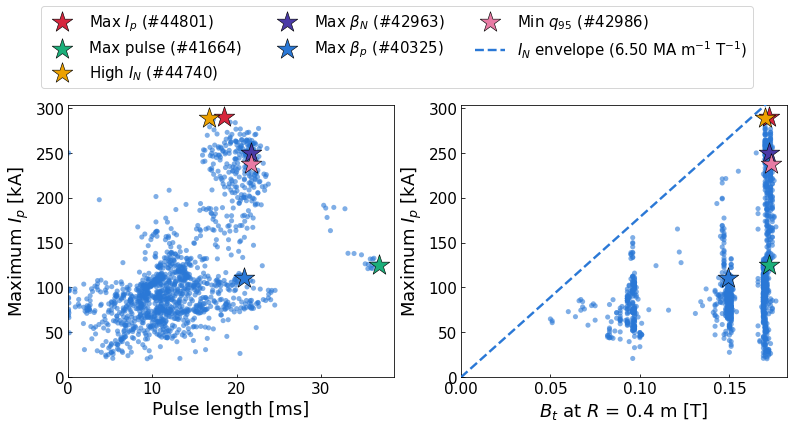

In [ ]:
# PPCF 2025 Fig. 6, redrawn: (a) I_p,max against pulse length, (b) I_p,max against B_t
pres = resolve_presentation(FORMAT, THEME)
with pres.context():
    width = pres.format.width_in
    fig, axs = plt.subplots(1, 2, figsize=(width, min(0.5 * width, pres.format.max_height_in - 1.2)))   # room for the legend
    for ax, x, xlabel in ((axs[0], "pulse_ms", "Pulse length [ms]"), (axs[1], "bt_04", "$B_t$ at $R$ = 0.4 m [T]")):
        ax.scatter(shots[x], shots["ip_max_kA"], s=0.5 * plt.rcParams["lines.markersize"] ** 2, color="#2a78d6",
                   alpha=0.6, edgecolors="none", zorder=2)
        draw_stars(ax, x, "ip_max_kA")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Maximum $I_p$ [kA]")
        ax.set_xlim(0, None)
        ax.set_ylim(0, None)
    bt = np.linspace(0, 1.05 * shots["bt_04"].max(), 50)
    axs[1].plot(bt, ENVELOPE * SHAPE["minor_radius"] * bt * 1e3, "--", color="#2a78d6", zorder=3,
                label=f"$I_N$ envelope ({ENVELOPE:.2f} MA m$^{{-1}}$ T$^{{-1}}$)")
    handles, labels = axs[0].get_legend_handles_labels()
    h1, l1 = axs[1].get_legend_handles_labels()
    extra = [(h, l) for h, l in zip(h1, l1) if l not in labels]
    fig.legend(handles + [h for h, _ in extra], labels + [l for _, l in extra], loc="lower center", ncol=3,
               frameon=True, fontsize="small", bbox_to_anchor=(0.5, 1.0))
    fig.tight_layout(pad=pres.pad)
    plt.show()

## Effective diagrams: analytic limits on the shot database at the mean shape

A shot in the shot sheet has no equilibrium, so its edge safety factor is not known. With the Tier A mean shape
($\bar a$, $\bar R_{geo}$, $\bar\kappa$, $\bar\delta$ above), the analytic formulas turn each limit into a maximum
current at a given field, a line through the origin of the $I_p$–$B_t$ plane:

- **Freidberg kink current limit** (Freidberg 2007, Eq. 13.163; **Analytical**):
  $I_{max} = (2\pi a^2 B_0/\mu_0 R_0)\,2\kappa/(1+\kappa)$, i.e. $q_* = 2\pi a^2\kappa B_0/(\mu_0R_0I) \ge (1+\kappa)/2$.
- **Menard current limit** (Menard et al., Phys. Plasmas 11 (2004) 639, after D'Ippolito et al. 1978;
  **Numerical**, low-aspect-ratio ideal no-wall scans, A = 1.6–3.3): with the cylindrical safety factor
  $q^* = \pi a^2 B_{T0}(1+\kappa^2)/(\mu_0 R_0 I_P)$, no stable case is found below $q^* = 1$ (and $\langle\beta_N\rangle$
  degrades below 2), so $I_{max} = \pi a^2 B_{T0}(1+\kappa^2)/\mu_0 R_0$.
- **ITER $q_{95}$ guideline** (Post et al., ITER Physics, ITER DS No. 21 (1991), Table 1-2, after Uckan 1990;
  **Empirical** design guideline): $q_{95} \approx \frac{5a^2B}{RI}\frac{1+\kappa^2(1+2\delta^2-1.2\delta^3)}{2}
  \frac{1.17-0.65\epsilon}{(1-\epsilon^2)^2} \ge 2.1$ (extended performance; 3.0 baseline), a conventional-aspect-ratio
  fit extrapolated to $A \approx 1.4$.
- **START $q_{95}$ scaling** (Akers et al., Nucl. Fusion 40 (2000) 1223, Sec. 2.1; **Empirical**, fitted to START
  spherical-tokamak equilibria): the same shaping factor with $f(A) = 1.17\,C\sqrt{A/(A-1)}$ in place of ITER's
  $(1.17-0.65/A)/(1-1/A^2)^2$, $C$ = 1.0 for a natural limiter plasma (VEST) and 0.77 for double null. Akers et al. give
  the scaling, not a limit; the line is the ITER guideline $q_{95}$ = 2.1 applied to it.

**These are not $q_a$.** $q_*$ and $q^*$ are global, shape-weighted proxies of the edge safety factor and $q_{95}$ here
is a fitted estimate; none is the equilibrium's $q_a$ or $q_{95}$. Both $q_{95}$ formulas are written for the 95 % surface
shape ($\kappa_{95}$, $\delta_{95}$); the last closed surface's values are used here.

The field axis is $B_T$ at the mean $R_{geo}$, $B_t(0.4\,\mathrm{m}) \cdot 0.4/\bar R_{geo}$ (a vacuum field falls as $1/R$),
because the formulas take the field at the plasma's own major radius. One shape for every shot makes these
*effective* limits: a shot more elongated than the mean has a higher limit than the line shows.

The last figure checks the proxies against the equilibria: for every Tier A state, each formula on the state's own
shape against the equilibrium's $q_{95}$.

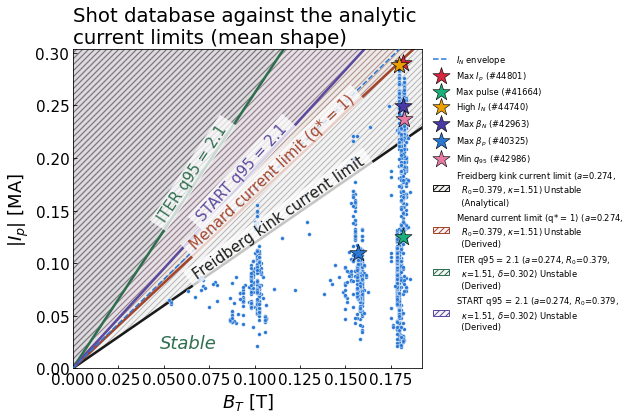

note: boundary 'freidberg_2008_kink_current' applies to: tokamak, elongated elliptical cross-section
note: boundary 'menard_2004_qstar_current' applies to: tokamak including spherical tokamaks
note: boundary 'akers_2000_q95_current' applies to: spherical tokamak (START equilibria), limiter plasma (C = 1.0)


                             I_N limit [MA/(m T)]  shots beyond  \
freidberg_2008_kink_current                  4.58           215   
menard_2004_qstar_current                    6.23             0   
iter_1991_q95_current                       10.07             0   
akers_2000_q95_current                       7.28             0   
observed envelope                            6.50             0   

                            over the shape IQR  
freidberg_2008_kink_current          3.09-6.61  
menard_2004_qstar_current            4.00-9.52  
iter_1991_q95_current               3.92-45.25  
akers_2000_q95_current              3.81-15.89  
observed envelope                               

Tier A equilibria: I_p <= 0.179 MA, I_N <= 3.80 in the shot-sheet definition; 337 shots exceed that I_N at their peak


In [ ]:
R_GEO = SHAPE["major_radius"]
shots["toroidal_field"] = shots["bt_04"] * 0.4 / R_GEO
shots["plasma_current"] = shots["ip_max_kA"] / 1e3
shots.attrs["units"] = {"toroidal_field": "T", "plasma_current": "MA", "normalized_current": "MA m^-1 T^-1"}
LIMIT_SHAPE = {k: SHAPE[k] for k in ("minor_radius", "major_radius", "elongation", "triangularity")}

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    fig, ax = operational_space_population(shots, "ip_bt", boundary_style="inline", legend_keys=False,
                                           boundary_inputs=LIMIT_SHAPE, x_range=(0.0, None), y_range=(0.0, None),
                                           title="Shot database against the analytic\ncurrent limits (mean shape)",
                                           format=FORMAT, theme=THEME, marker_size=10)
    bt = np.linspace(0, ax.get_xlim()[1], 50)
    # the envelope in this field: I = I_N a B(0.4 m) = I_N a B_geo R_geo / 0.4
    ax.plot(bt, ENVELOPE * SHAPE["minor_radius"] * bt * R_GEO / 0.4, "--", color="#2a78d6", zorder=3,
            label="$I_N$ envelope")
    draw_stars(ax, "toroidal_field", "plasma_current")
    relegend(ax)
    plt.show()
for message in dict.fromkeys(str(w.message) for w in caught):
    print("note:", message)

# where each limit sits in normalised current, and how much of the database lies beyond it
lim = {}
for key in ("freidberg_2008_kink_current", "menard_2004_qstar_current", "iter_1991_q95_current",
            "akers_2000_q95_current"):
    entry = B.get_boundary(key)
    i_at_1T = float(B.boundary_value(entry, toroidal_field=1.0, **{k: v for k, v in LIMIT_SHAPE.items()
                                                                   if k in entry.input_names}))
    # I_lim = i_at_1T B_geo and I_N = I/(a B(0.4 m)) with B(0.4 m) = B_geo R_geo/0.4
    lim[key] = i_at_1T * 0.4 / (SHAPE["minor_radius"] * R_GEO)
summary = pd.DataFrame({"I_N limit [MA/(m T)]": lim})
summary["shots beyond"] = [int((shots["normalized_current"] > v).sum()) for v in summary.iloc[:, 0]]


def in_limit(key, a, R, kappa, delta):
    entry = B.get_boundary(key)
    shape = {"minor_radius": a, "major_radius": R, "elongation": kappa, "triangularity": delta}
    i1 = float(B.boundary_value(entry, toroidal_field=1.0, **{k: v for k, v in shape.items() if k in entry.input_names}))
    return i1 * 0.4 / (SHAPE["minor_radius"] * R)   # in the shot sheet's I_N (mean a, field at 0.4 m)


# how far each limit moves across the Tier A shape spread (the lowest and highest corners of the quartile box)
q = mag[["minor_radius", "major_radius", "elongation", "triangularity"]].quantile([0.25, 0.75])
corners = [(a, R, k, d) for a in q["minor_radius"] for R in q["major_radius"] for k in q["elongation"]
           for d in q["triangularity"]]
summary["over the shape IQR"] = [f"{min(in_limit(k, *c) for c in corners):.2f}-{max(in_limit(k, *c) for c in corners):.2f}"
                                 for k in summary.index]
summary.loc["observed envelope"] = [ENVELOPE, 0, ""]
display(summary.round(2))
# the equilibria in the same I_N (mean a, field at 0.4 m) as the shot sheet
mag_in = mag["plasma_current"] / (SHAPE["minor_radius"] * mag["b0_t"])
print(f"Tier A equilibria: I_p <= {mag['plasma_current'].max():.3f} MA, I_N <= {mag_in.max():.2f} in the shot-sheet "
      f"definition; {int((shots['normalized_current'] > mag_in.max()).sum())} shots exceed that I_N at their peak")

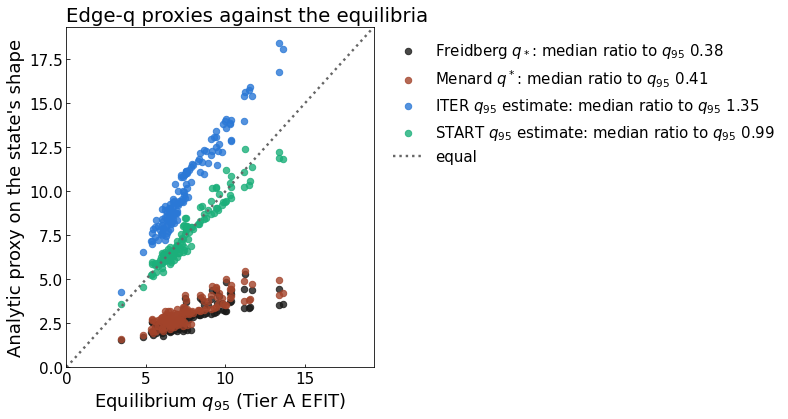

                         count   25%   50%   75%
Freidberg $q_*$          133.0  0.34  0.38  0.41
Menard $q^*$             133.0  0.37  0.41  0.44
ITER $q_{95}$ estimate   133.0  1.29  1.35  1.41
START $q_{95}$ estimate  133.0  0.95  0.99  1.03

In [ ]:
# the proxies against the equilibria: each formula on the state's own shape, against the equilibrium q95
proxy = pd.DataFrame({
    "equilibrium $q_{95}$": mag["edge_safety_factor_95"],
    "Freidberg $q_*$": B.kink_coordinates(mag["minor_radius"], mag["major_radius"], mag["toroidal_field"],
                                         mag["elongation"], mag["plasma_current"]),
    "Menard $q^*$": B.cylindrical_kink_coordinates(mag["minor_radius"], mag["major_radius"], mag["toroidal_field"],
                                                   mag["elongation"], mag["plasma_current"]),
    "ITER $q_{95}$ estimate": B.iter_q95_coordinates(mag["minor_radius"], mag["major_radius"], mag["toroidal_field"],
                                                     mag["elongation"], mag["triangularity"], mag["plasma_current"]),
    "START $q_{95}$ estimate": B.start_q95_coordinates(mag["minor_radius"], mag["major_radius"], mag["toroidal_field"],
                                                       mag["elongation"], mag["triangularity"], mag["plasma_current"]),
}).dropna()
with pres.context():
    fig, ax = plt.subplots(figsize=(pres.format.width_in, min(0.55 * pres.format.width_in, pres.format.max_height_in)))
    q = proxy["equilibrium $q_{95}$"]
    for col, c in zip(proxy.columns[1:], ("#1a1a19", "#a3442b", "#2a78d6", "#1baf7a")):
        ratio = proxy[col] / q
        ax.scatter(q, proxy[col], s=0.8 * plt.rcParams["lines.markersize"] ** 2, color=c, alpha=0.8,
                   label=f"{col}: median ratio to $q_{{95}}$ {ratio.median():.2f}")
    top = 1.05 * float(np.nanmax(proxy.to_numpy()))
    ax.plot([0, top], [0, top], ":", color="0.4", label="equal")
    ax.set_xlim(0, top)
    ax.set_ylim(0, top)
    ax.set_xlabel("Equilibrium $q_{95}$ (Tier A EFIT)")
    ax.set_ylabel("Analytic proxy on the state's shape")
    ax.set_title("Edge-q proxies against the equilibria", loc="left")
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize="small")
    fig.tight_layout(pad=pres.pad)
    plt.show()
display((proxy.iloc[:, 1:].div(proxy.iloc[:, 0], axis=0)).describe().T[["count", "25%", "50%", "75%"]].round(2))

**Interpretation.**

- **At the mean shape, the database's largest normalised current sits near the low-aspect-ratio ideal current limit, and above the conventional one.** At the Tier A median shape ($\bar a$ = 0.274 m, $\bar R_{geo}$ = 0.379 m, $A$ = 1.38, $\bar\kappa$ = 1.51, $\bar\delta$ = 0.30) the limits sit at $I_N$ = 4.58 (Freidberg, $q_* = (1+\kappa)/2$), 6.23 (Menard, $q^* = 1$), 7.3 (START $q_{95}$ = 2.1) and 10.1 (ITER $q_{95}$ = 2.1) MA m$^{-1}$ T$^{-1}$, and the largest $I_N$ is 6.19 (#44740). This is *consistent with* Menard's $q^* = 1$ limit, not a measurement of it: each line scales with the shape ($I_N \propto a(1+\kappa^2)/R^2$ for Menard), and over the Tier A shape quartiles the Menard limit spans 4.0–9.5 (and Freidberg's 3.1–6.6; table above). Menard's scans also cover $A$ = 1.6–3.3, so at $A$ = 1.38 the limit itself is extrapolated.
- **Freidberg's line is crossed only under the mean-shape assumption.** 215 of the 1382 flagged shots (191 at $B_t \approx 0.17$ T) lie beyond it at the mean shape, but every Tier A equilibrium, each on its own shape, stays below it ($I_p/I_{max} \le 0.76$). The high-current shots need their own shape at the current peak to decide whether $(1+\kappa)/2$ is exceeded.
- **The converged equilibria do not sample the peak current.** In the same $I_N$ definition as the shot sheet (mean $a$, field at 0.4 m), the Tier A reconstructions reach $I_N \le 3.8$ ($I_p \le 0.18$ MA), and several hundred shots (printed above) exceed that at their peak: the high-current, short-pulse corner (#44801, 290 kA) is where the shot summary has data and the equilibrium planes do not.
- **The START scaling reproduces VEST's $q_{95}$; the others do not.** On the Tier A states' own shapes, the START estimate of Akers et al. is 0.99 of the equilibrium $q_{95}$ (median; interquartile 0.95–1.03), while the ITER guideline formula gives 1.35 and Freidberg's $q_*$ and Menard's $q^*$ are 0.38 and 0.41 of it. The conventional-aspect-ratio $f(A)$ misses the low-$A$ toroidal enhancement that the START fit, built on spherical-tokamak equilibria, captures, and it does so even though both formulas are fed the last closed surface's $\kappa$ and $\delta$ rather than the 95 % surface values they are written for. For a VEST shot without an equilibrium, the START estimate is the usable $q_{95}$; $q_*$ and $q^*$ are different quantities and must be compared only with limits stated on them.
- **With the START estimate, the q95 = 2.1 guideline sits at $I_N$ = 7.3 at the mean shape**, above every shot in the database (largest 6.19); no VEST shot in the sheet reaches $q_{95} \approx 2$ by this estimate.
- **Stars:** the highest-$\beta_N$ (#42963, 2.42), highest-$\beta_p$ (#40325, 0.59) and lowest-$q_{95}$ (#42986, 3.44) equilibria are high-current 429xx/403xx discharges. The most elongated state (#39915, $\kappa$ = 1.78) is not drawn: the legacy sheet has a row for it, but not flagged `has_efit_ods` (and with a 0.08 ms pulse length), so it is outside the plotted population.

## Limit 1: the external kink limit, $q_*$ against $I_N$

**What it is.** The current-driven external kink limits how much current an elongated plasma can carry at a given
field. Freidberg (2008, ch. 13) writes the edge safety factor of an elliptical plasma as the *kink safety factor*
$q_* = 2\pi a^2 \kappa B_0 / (\mu_0 R_0 I_p)$ (Eq. 13.160), and the ideal-MHD condition against the external kink as
$q_* \ge (1+\kappa)/2$ (Eq. 13.162). **Analytical** (ideal MHD, elliptical cross-section, $1 < \kappa < 2$).

**On this plane.** $x = I_N = I_p/(aB_T)$, $y = q_*$. The limit depends on $\kappa$, so it is drawn at the largest
elongation in the population: the most permissive line, which every state must clear if it clears its own.
(The printed Eqs. 5 and 7 of Yun et al., PPCF 67 (2025) 115021, differ from Freidberg; its Fig. 8 lines are
Eqs. 13.162–13.163, #1524.)

Kink safety factor against normalized current: 150 of 150 states have both coordinates


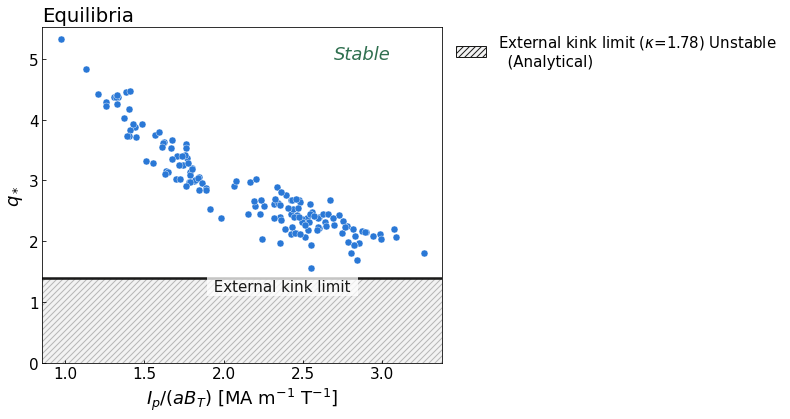

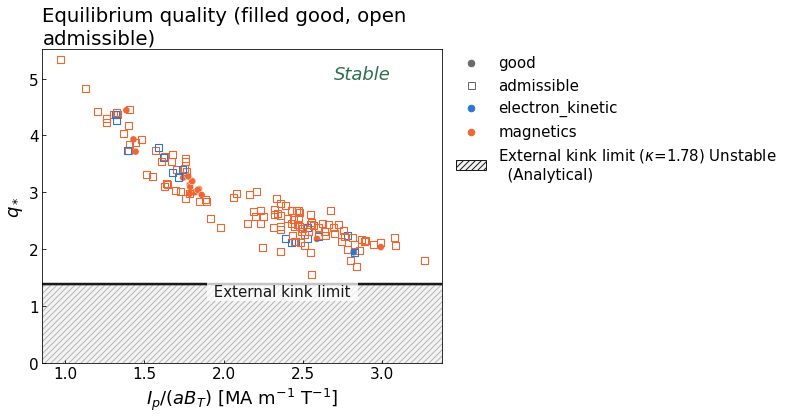

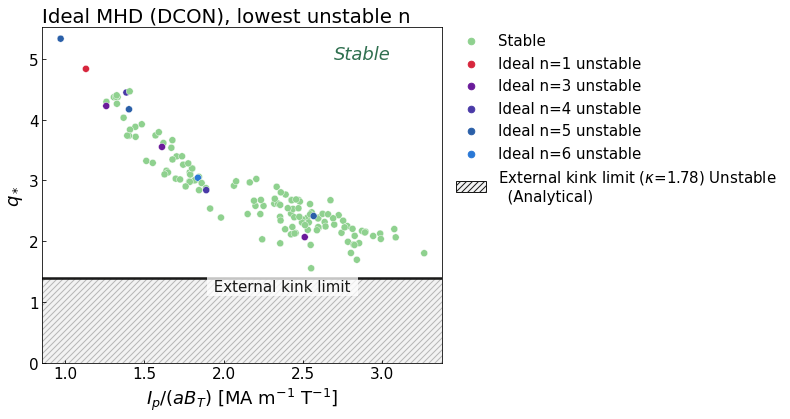

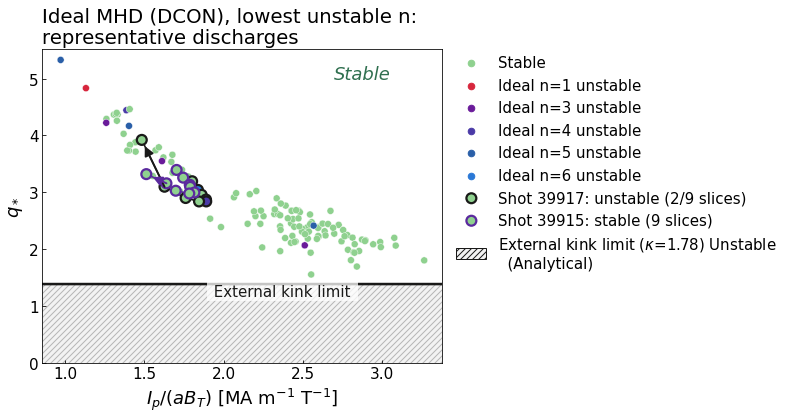

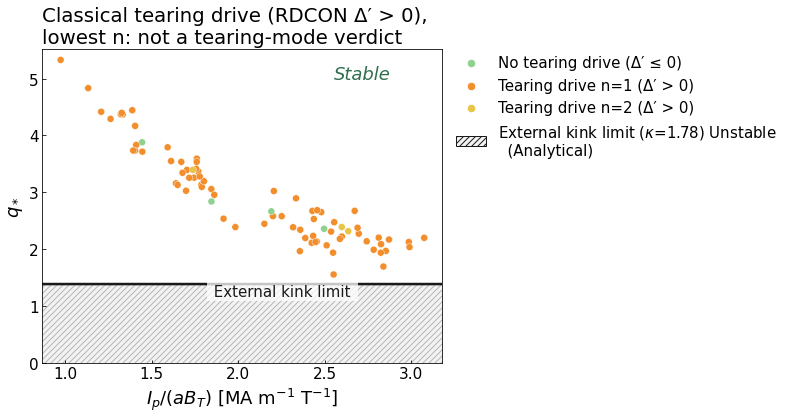

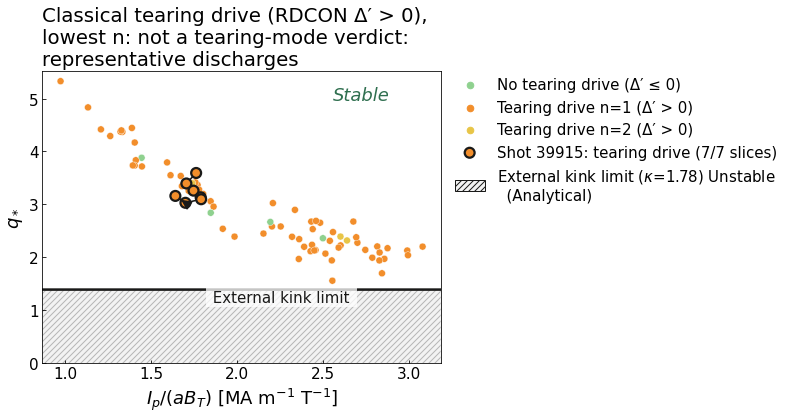

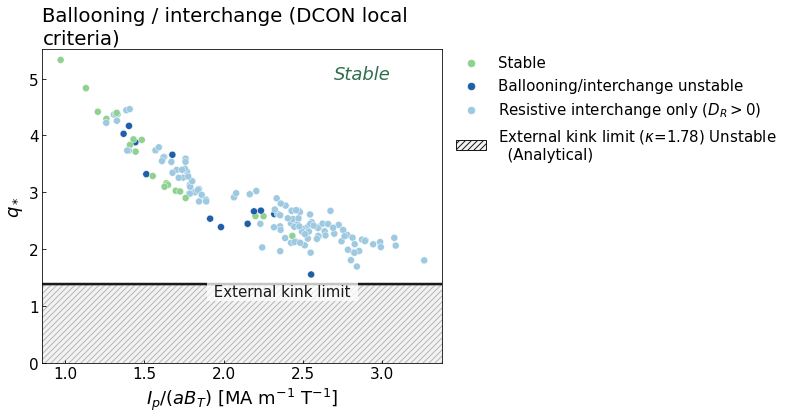

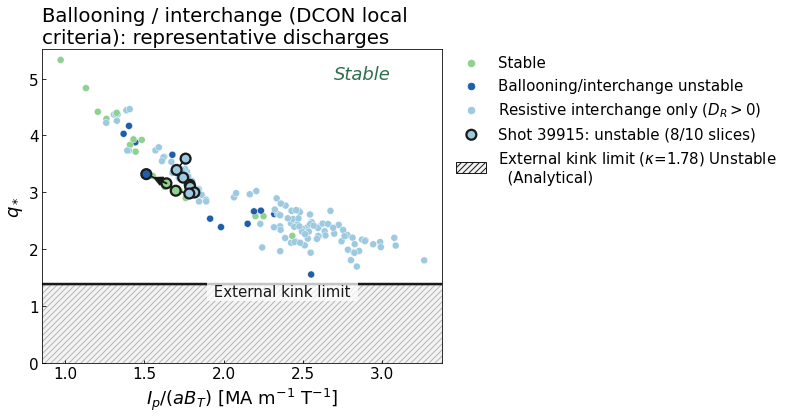

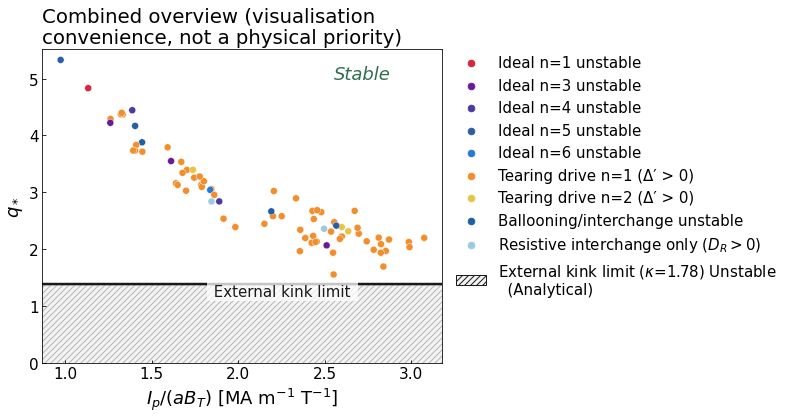

note: boundary 'freidberg_2008_kink_qstar' applies to: tokamak, elongated elliptical cross-section


In [ ]:
KAPPA_MAX = float(T["elongation"].clip(upper=2.0).max())   # Freidberg's limit holds for 1 < kappa < 2
section("qstar_in", boundary_inputs={"elongation": KAPPA_MAX}, y_range=(0.0, None))

**Interpretation.**

- **No state reaches the analytical external-kink limit.** $q_*$ spans 1.56–5.33 and the margin $q_*/[(1+\kappa)/2]$ evaluated at each state's own $\kappa$ is 1.32–4.68 (median 2.1). VEST's Tier A operation is therefore not current-limited by the $m = 1$ external kink in the sense of Freidberg's criterion.
- **The population lies on one band** $q_* \propto 1/I_N$, as expected: $q_* = 2\pi\kappa/(\mu_0 R_0/a \cdot I_N)$, so the spread across the band is the spread in $\kappa$ and aspect ratio.
- **Ideal MHD (DCON, $n = 1$–6):** 10 states are robustly unstable ($n = 1$: 1, $n = 3$: 3, $n = 4$: 2, $n = 5$: 3, $n = 6$: 1). They sit at the *high*-$q_*$, low-$I_N$ end of the band (median $q_*$ 3.9 and $I_N$ 1.5, against 2.6 and 2.4 for the stable states), not near the line, and every one of them is stable at its lowest unstable $n$ when the edge is truncated: they are edge-sensitive, mostly medium-$n$ instabilities, not the global current-limit kink this line describes. (The edge treatment shows sensitivity to the edge region; it does not by itself classify a mode as peeling or kink, #1607.) Two of them (39906 and 40324) stay unstable at $n = 6$ even with the edge truncated, so at the highest $n$ they also have an interior drive. Yun et al. (2025) found edge-localised $n = 1$ instabilities at rational $q_a$; these results extend the edge sensitivity to $n = 3$–6.
- **Classical tearing drive:** $\Delta' > 0$ at some surface is the rule rather than the exception (at $n = 1$, 73 of the 93 resolution-robust states; 73 of the 80 states classified at every $n$) and shows no trend with $q_*$ or $I_N$; the robustly $\Delta' \le 0$ states (20 at $n = 1$, 4 at both $n$) are scattered across the band. On this plane the classical drive does not mark an operating boundary.
- **Representative discharges** move along the band toward lower $I_N$ as the current falls (ideal: 39915 stable throughout, 39917 unstable at two of nine slices, $n = 6$ at 318 ms and $n = 4$ at 321 ms, stable between; tearing drive: 39915, $\Delta' > 0$ throughout). The ideal instability of 39917 appears and disappears between adjacent 1 ms slices, as an edge-resonant mode would.

## Limit 2: the kink current limit, $I_p$ against $\kappa$

**What it is.** The same condition written as a maximum current, $I_{max} = (2\pi a^2 B_0/\mu_0 R_0)\,
2\kappa/(1+\kappa)$ (Freidberg 2008, Eq. 13.163). It rises by 4/3 from $\kappa = 1$ to 2: elongation buys current.
**Analytical.**

**On this plane.** $x = \kappa$, $y = |I_p|$ [MA]. The line needs $a$, $R_0$ and $B_0$, taken at the population
median, so it is the limit of a typical VEST shape, not of each state.

Plasma current against elongation: 150 of 150 states have both coordinates


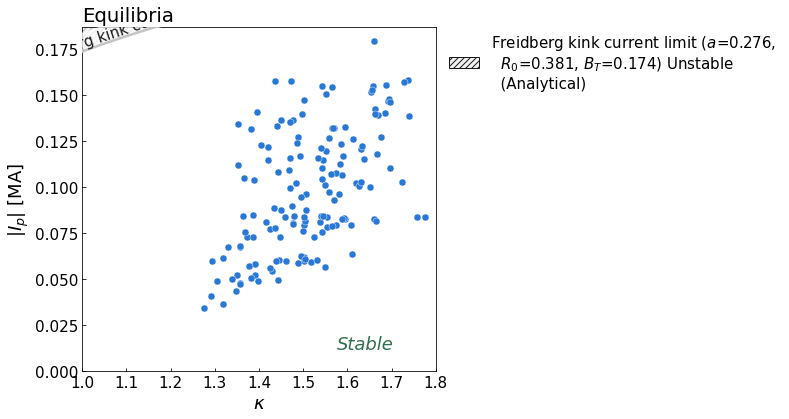

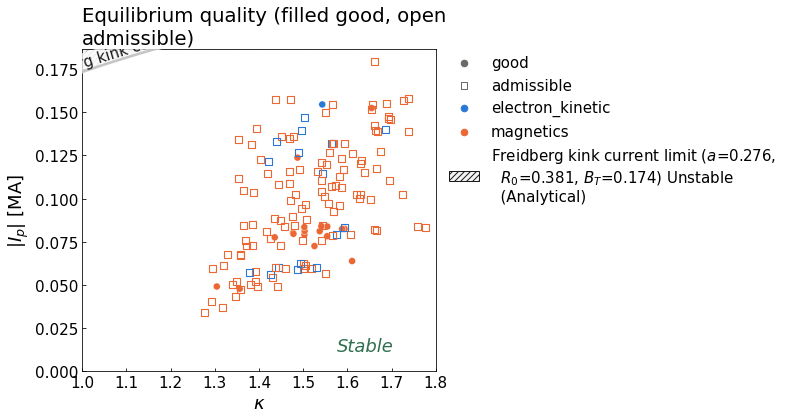

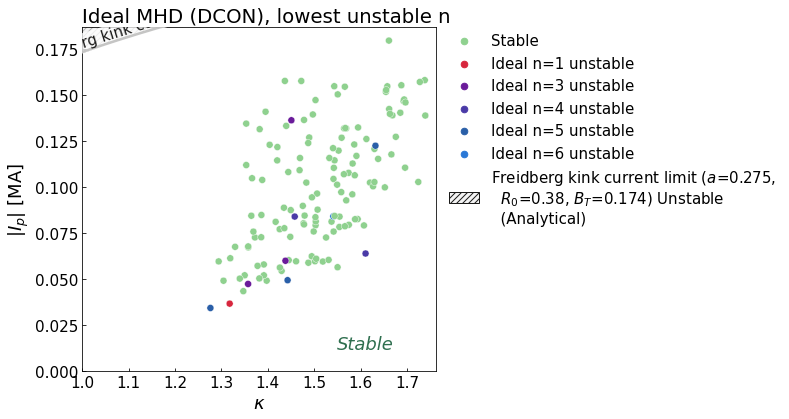

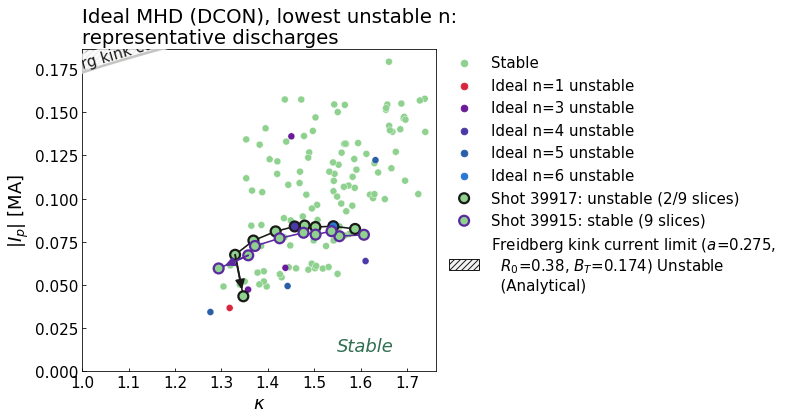

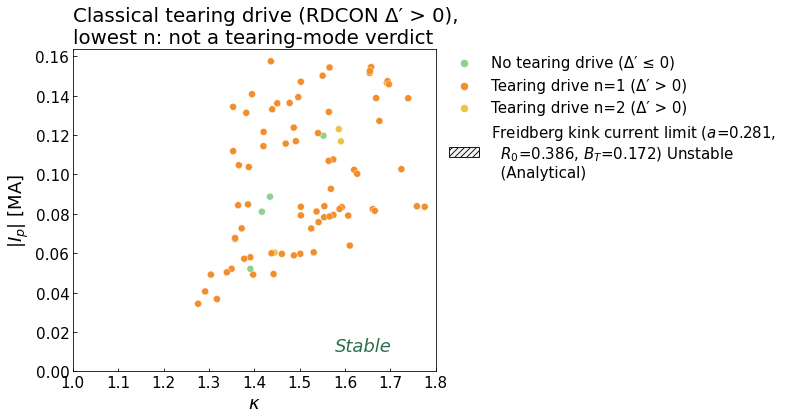

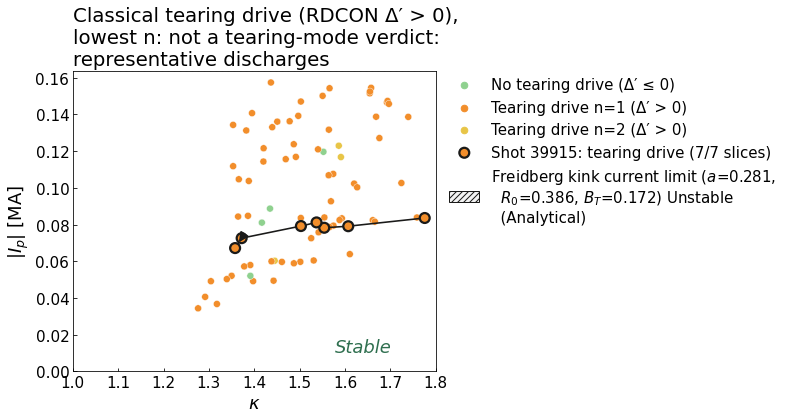

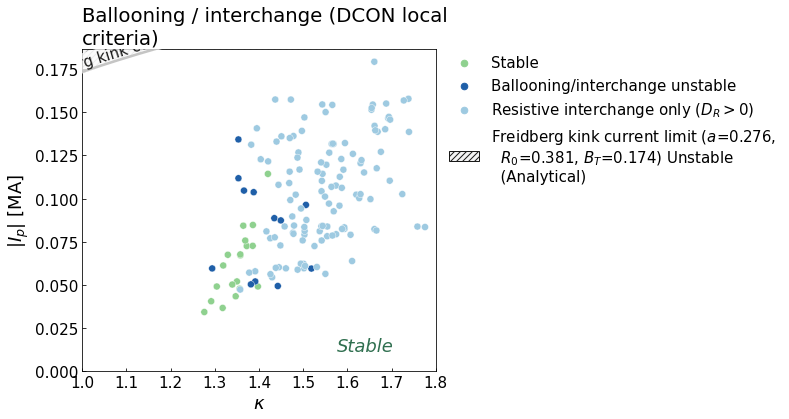

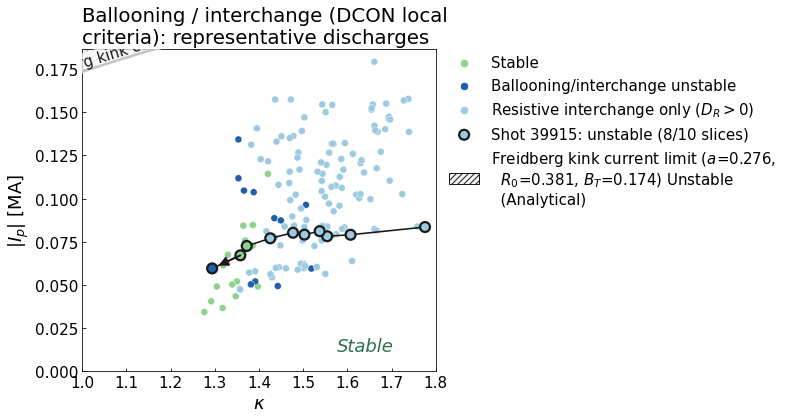

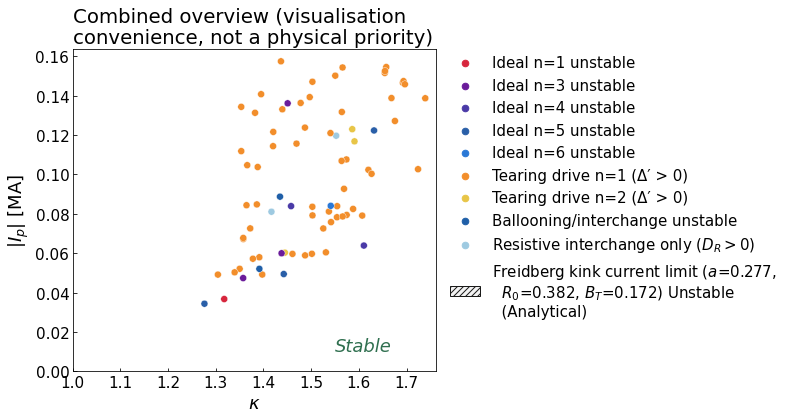

note: boundary 'freidberg_2008_kink_current' applies to: tokamak, elongated elliptical cross-section


In [ ]:
section("ip_kappa", x_range=(1.0, None), y_range=(0.0, None))

**Interpretation.**

- **Current is far below the elongation-dependent maximum:** $I_p/I_{max}$ is 0.21–0.76 (median 0.48) when $I_{max}$ (Eq. 13.163) is evaluated with each state's own $a$, $R_0$, $B_0$ and $\kappa$. The line drawn at the population-median shape shows the same picture.
- **Higher current comes with higher elongation** across the population ($\kappa$ 1.28–1.78), the trend the limit rewards (Spearman ρ = 0.53 between $|I_p|$ and $\kappa$).
- The stability classes overlap completely on this plane, as on Limit 1: neither the ideal verdict nor the classical tearing drive is organised by $I_p$ or $\kappa$ alone.

## Limit 3: the Troyon beta limit, $\beta_T$ against $I_N$

**What it is.** The pressure-driven ideal limit: $\beta_T\,[\%] \le \beta_N^{max} I_N$ with
$\beta_N^{max} = 2.2\,\mu_0 \cdot 10^6 \approx 2.76$ % m T/MA (Troyon et al. 1984, n = 1 free-boundary kink without a
wall, optimised pressure profiles). **Numerical** (a fit to ideal-MHD stability calculations at conventional aspect
ratio $R/a = 2.4$–4; VEST is at 1.3).

**On this plane.** $x = I_N$, $y = \beta_T$ [%]: the limit is a line through the origin.

Troyon beta limit: 150 of 150 states have both coordinates


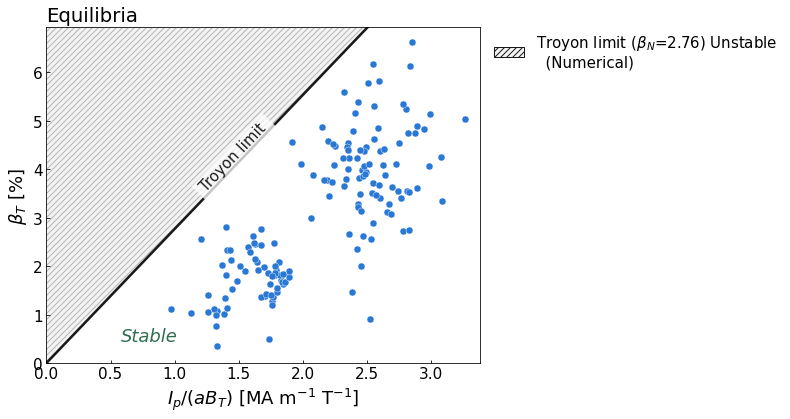

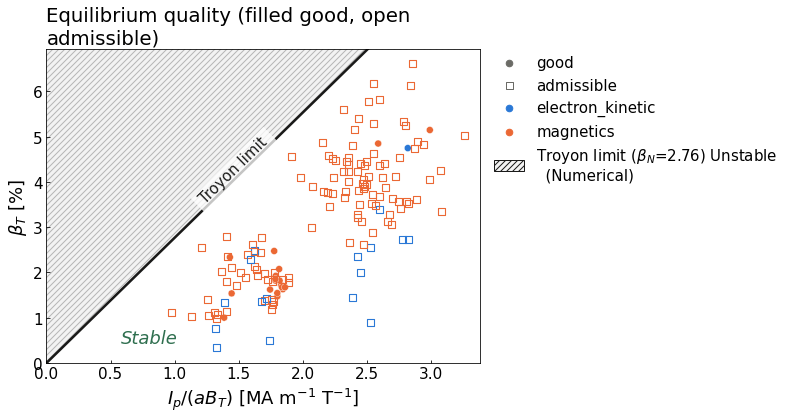

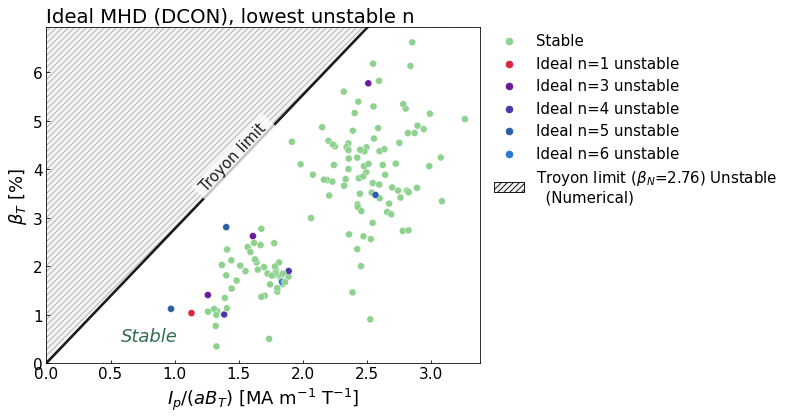

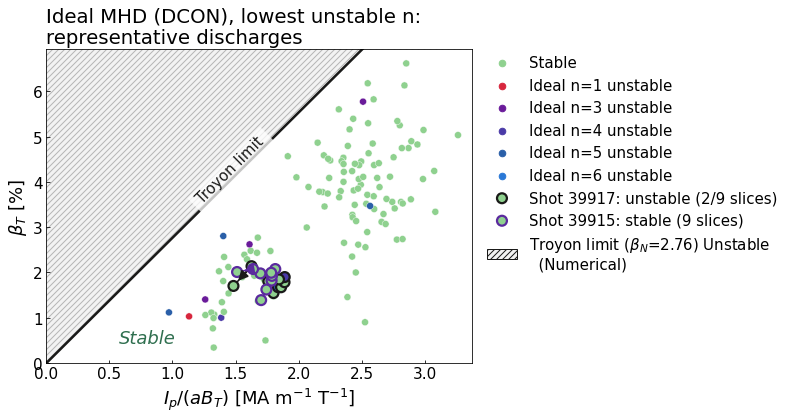

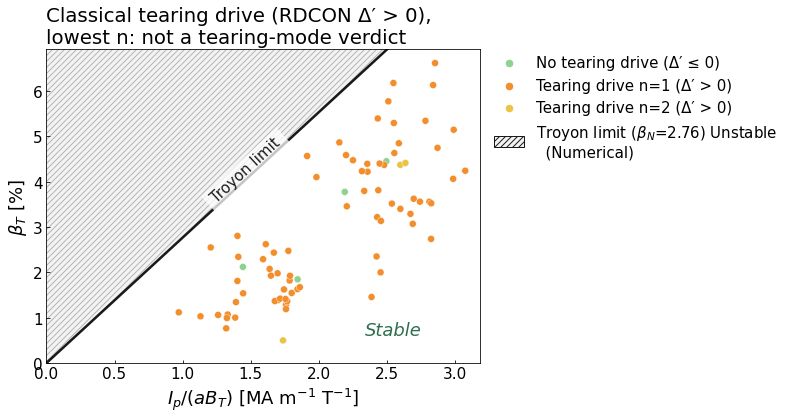

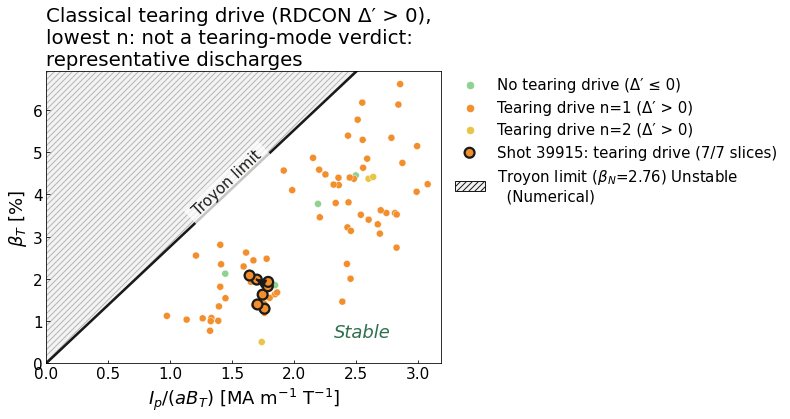

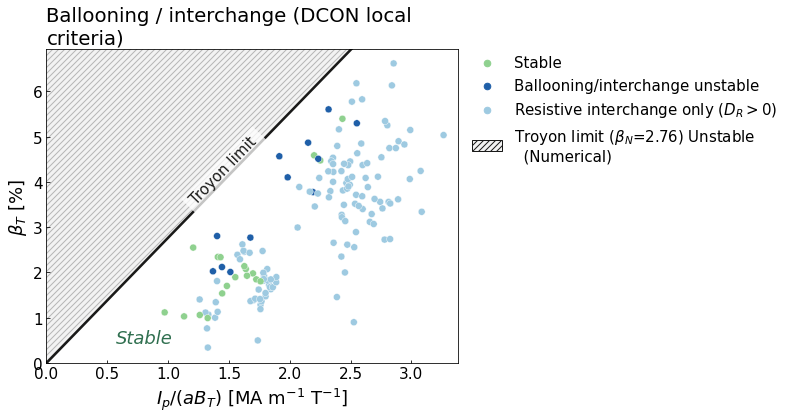

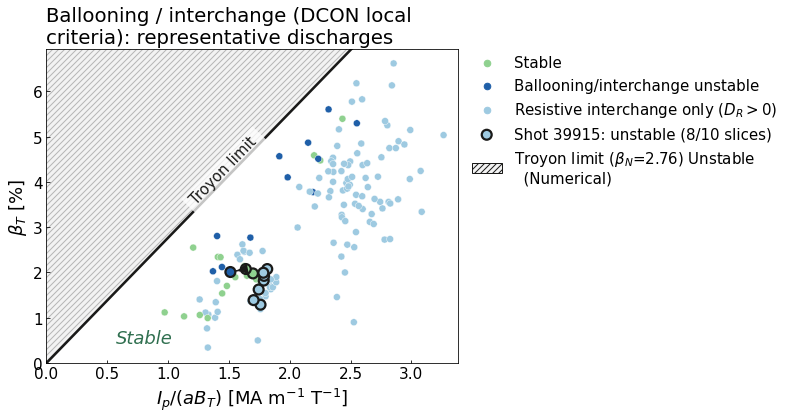

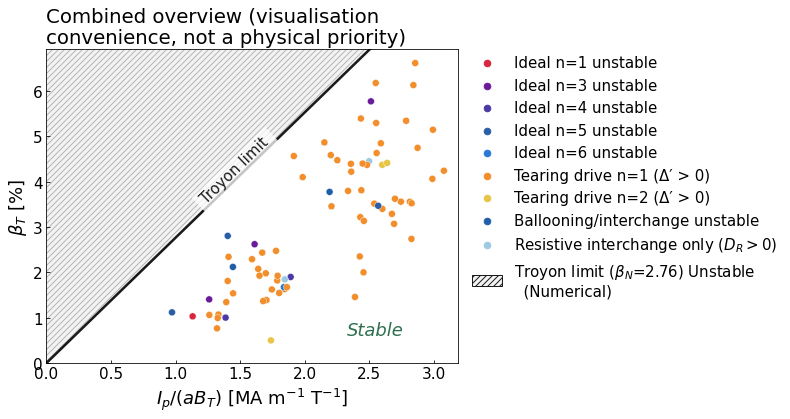

In [ ]:
section("troyon", x_range=(0.0, None), y_range=(0.0, None))

**Interpretation.**

- **All states are below the Troyon line.** The highest $\beta_N$ is 2.42 % m T/MA, 0.88 of the registered 2.76. Fifteen states have $\beta_N > 2$.
- **Caution on the pressure:** $\beta$ here is the magnetics-only (or electron-kinetic) EFIT pressure. Lane K's $R_W$ (EFIT pressure integral over the Thomson electron-pressure integral) has a median of 3.4 on the magnetics lineage and 2.1 on the electron-kinetic one; for the $\beta_N > 2$ states with Thomson it is 2.5–37 (median 4.0), more than the $\le 2$ that ions at $T_i \le T_e$ can supply. The high-$\beta_N$ end of this plane is therefore likely to be an over-estimate of the pressure by the magnetics fit, and the electron-kinetic lineage sits lower (median $\beta_N$ 0.96 vs 1.46).
- **Stability:** one of the 15 states with $\beta_N > 2$ is ideally unstable (42895, $n = 3$, edge-driven), and the ideal-unstable states have a *lower* median $\beta_T$ than the stable ones (1.8 % against 3.4 %): the ideal verdict does not follow the distance to the Troyon line, consistent with the paper's conclusion that VEST is not limited by the global pressure limit. The *local* pressure-driven criteria do follow $\beta$: the median $\beta_T$ is 3.9 % for the ballooning/interchange-unstable states, 3.4 % for the resistive-interchange-only states and 1.9 % for the locally stable ones.

## Limit 4: normalised beta against internal inductance, $\beta_N$ against $l_i(3)$

**What it is.** The same Troyon limit as a horizontal line, $\beta_N \le 2.76$, against the current-profile peaking
$l_i(3)$. Peaked current profiles (high $l_i$) raise the achievable $\beta_N$ in conventional tokamaks; an
$l_i$-scaled limit ($\beta_N \approx 4 l_i$) is often quoted but is not in the registry, so it is not drawn.
**Numerical.**

**On this plane.** $x = l_i(3)$ (the DD definition), $y = \beta_N$ [% m T/MA].

Normalized beta against internal inductance: 150 of 150 states have both coordinates


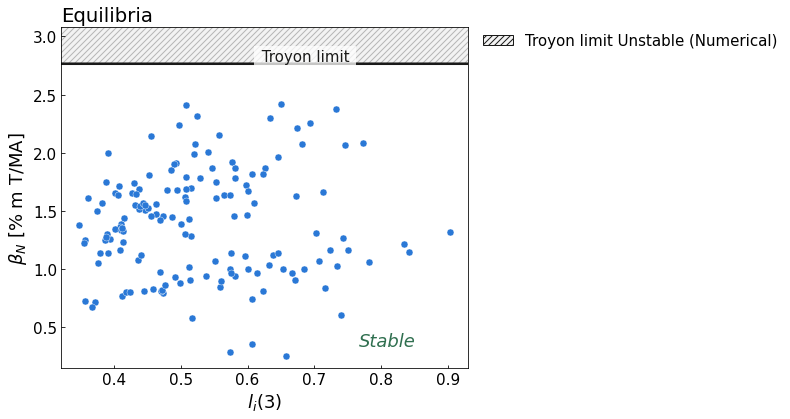

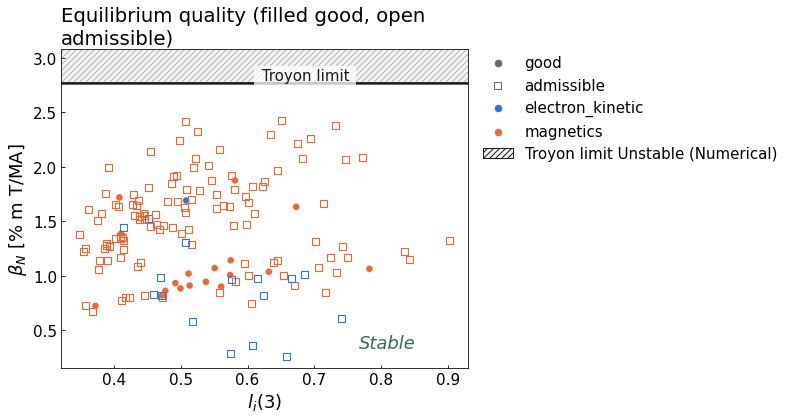

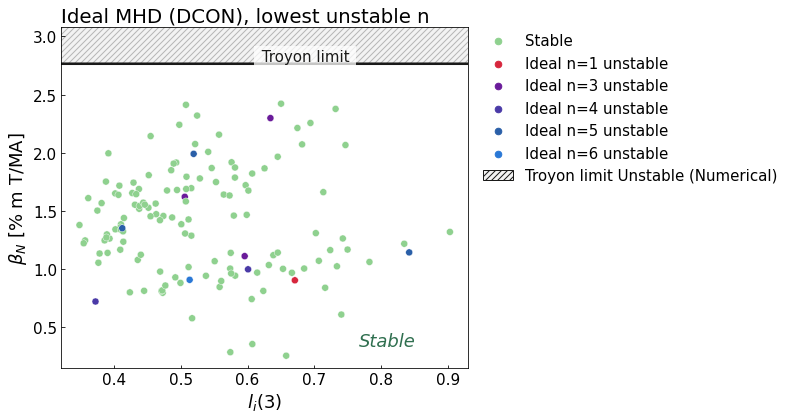

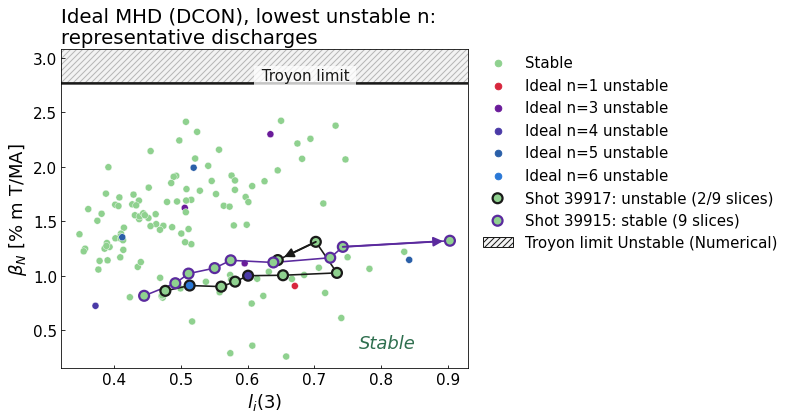

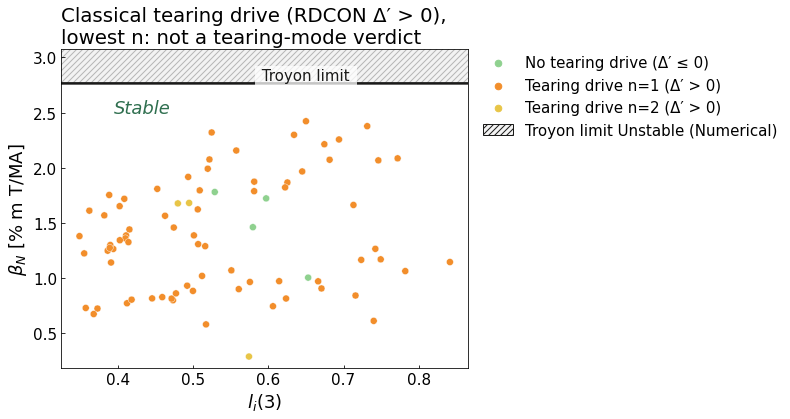

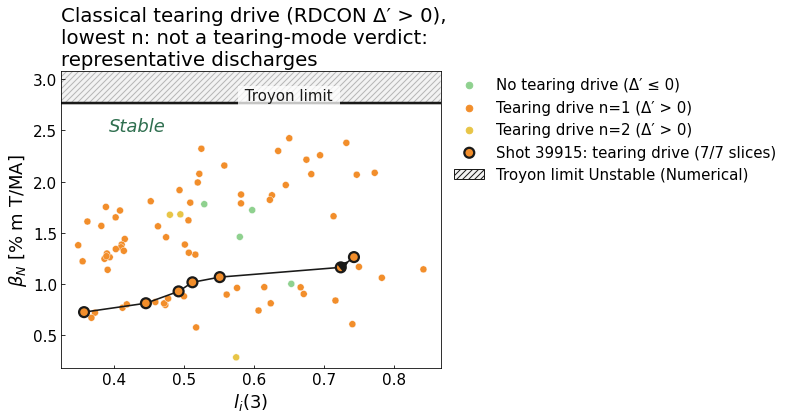

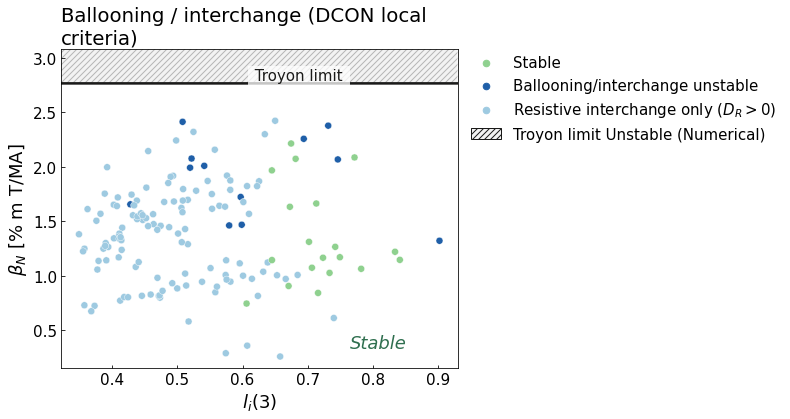

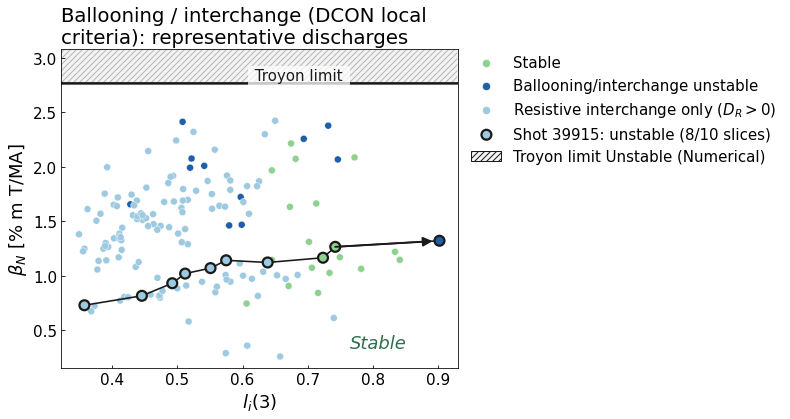

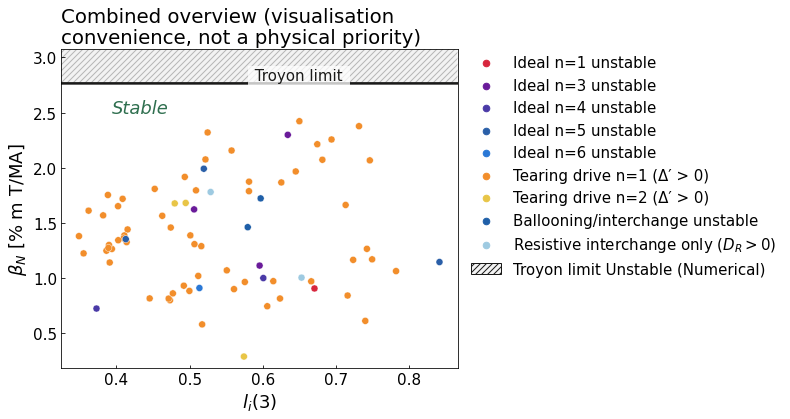

In [ ]:
section("beta_n_li")

**Interpretation.**

- The population fills $l_i(3)$ 0.35–0.90 and $\beta_N$ 0.26–2.42, entirely below the Troyon line.
- **Ballooning/interchange instability grows with both pressure and current peaking:** the representative discharge 39915 goes from resistive-interchange-only through stable to ballooning-unstable as $l_i$ rises from 0.36 to 0.90 during the ramp-down; the ballooning-unstable states have their worst $C_A$ near the axis (median $\psi_N = 0.06$), where a peaking current profile flattens the shear.
- The tearing-drive classes show no separation with $\beta_N$ or $l_i$ on this plane; the ideal-unstable states sit at slightly lower $\beta_N$ (median 1.13 against 1.42) and similar $l_i$ (0.56 against 0.51), consistent with an edge-sensitive rather than a pressure-driven instability.

## Limit 5: edge safety factor against internal inductance, $q_{95}$ against $l_i(3)$

**What it is.** The plane on which current-profile limits are usually discussed. The registered limit on $q_{95}$ is the
ITER design guideline $q_{95} \ge 2.1$ for $\kappa < 2$ (extended performance; 3.0 baseline; Post et al., ITER DS No. 21
(1991), Table 1-2): a design margin at conventional aspect ratio, not a measured stability limit. **Empirical.** The JET
and Cheng $l_i$ boundaries use $q_\psi$ at the edge and a cylinder's $q(a)$ (Limit 6), so they are not drawn here.

**On this plane.** $x = q_{95}$, $y = l_i(3)$.

Internal inductance against q95: 150 of 150 states have both coordinates


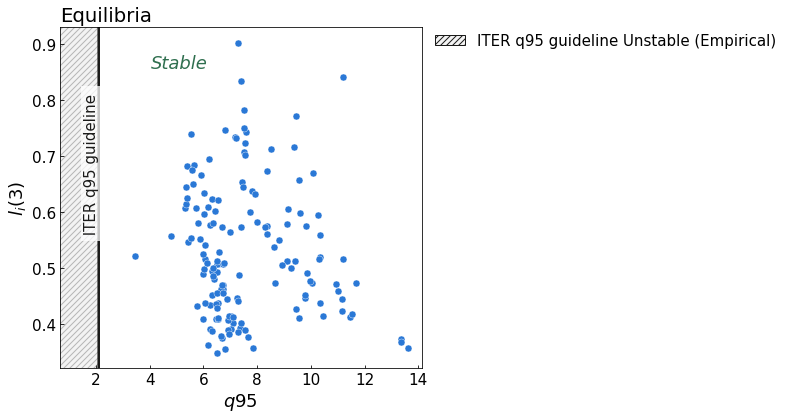

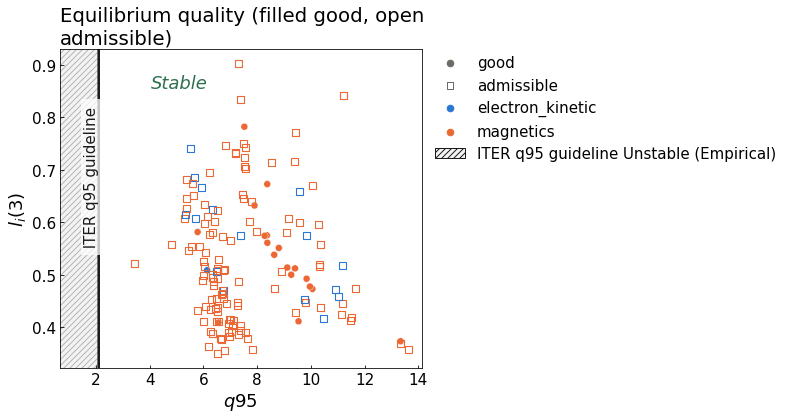

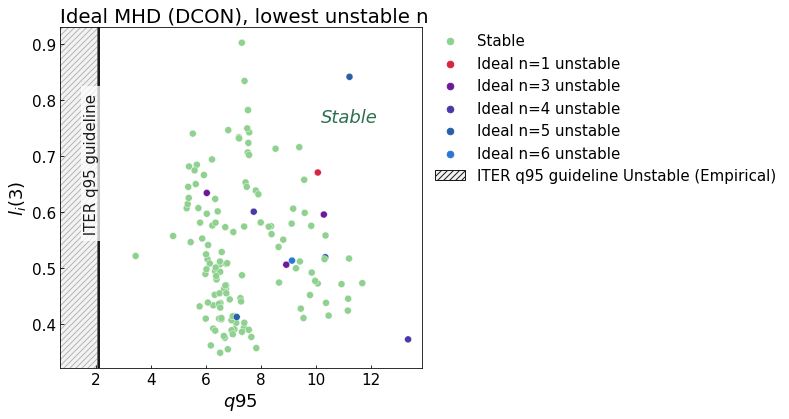

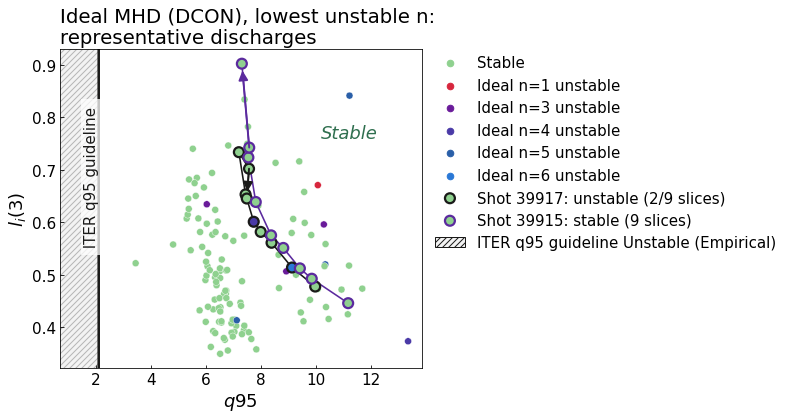

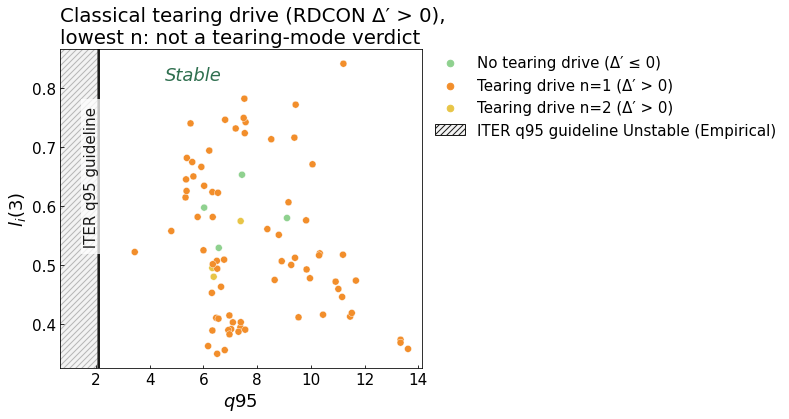

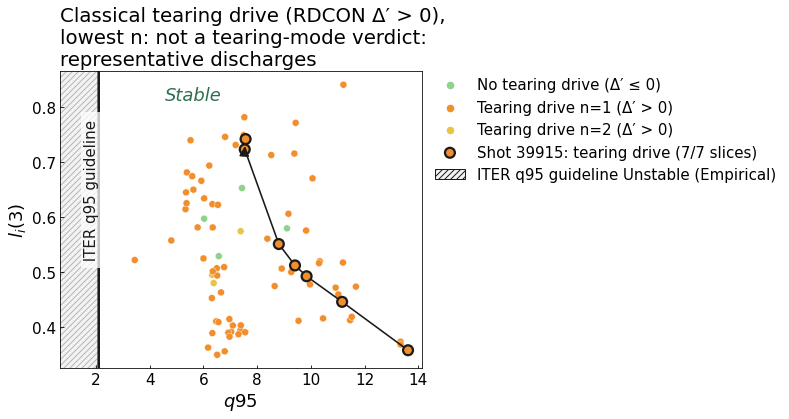

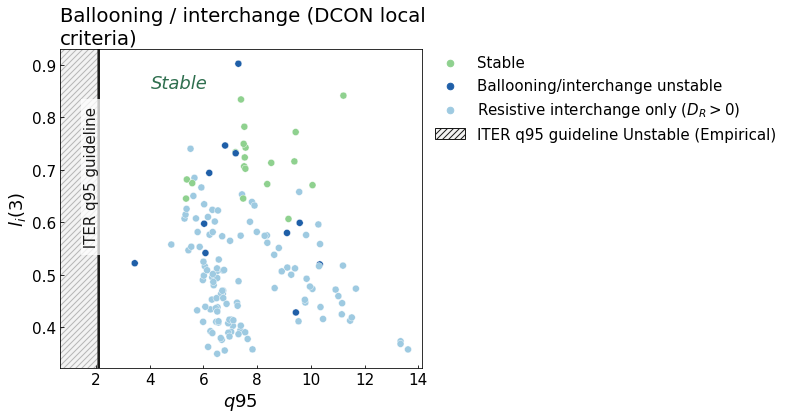

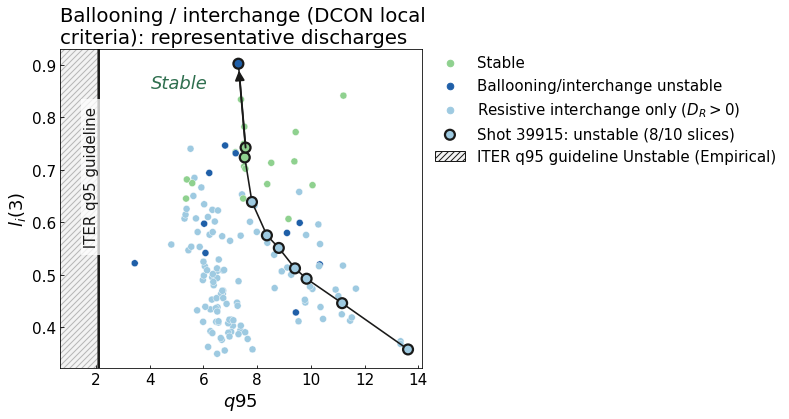

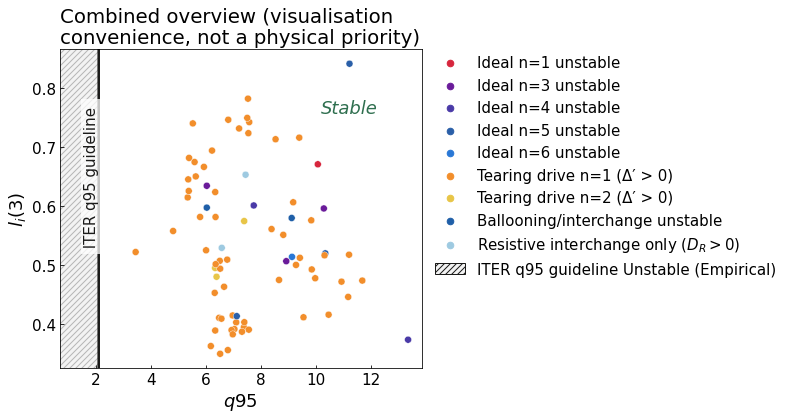

In [ ]:
section("q95_li")

**Interpretation.**

- VEST's Tier A states have high edge $q$ ($q_{95}$ 3.4–13.6, median 7.0) and low-to-moderate $l_i(3)$ (0.35–0.90, median 0.51): broad current profiles at low current, typical of the ramp-up and early ramp-down of a short, capacitor-driven discharge.
- Representative discharges move toward lower $q_{95}$ and higher $l_i$ in time, i.e. the current profile peaks while the total current falls.
- Every state is far above the ITER $q_{95}$ guideline (lowest $q_{95}$ 3.44 against 2.1, and above even the 3.0 baseline): no Tier A equilibrium approaches the low-$q$ limit, and the stability classes overlap across the plane.

## Limit 6: the JET $l_i$–$q_\psi$ operating space

**What it is.** Wesson et al., Nucl. Fusion 29 (1989) 641, Fig. 6: the operating space of JET discharges. Below the
lower, saw-tooth boundary, rotating kink and double-tearing modes grow during the current rise; above the upper
boundary, density-limit disruptions occur; $q_\psi = 2$ is the low-$q$ limit. **Empirical** (JET, $R = 3$ m,
conventional aspect ratio, $q_\psi$ 2–10).

**On this plane.** $x = q_\psi$ at the edge (not $q_{95}$), $y = l_i(3)$. The lines are a reference: VEST's aspect ratio
is outside JET's. They stop at $q_\psi$ = 2 and 10 because JET's Fig. 6 covers only that range; nothing is implied beyond
it, and the plotted data are not cut there (states up to $q_\psi \approx 18$ are shown).

JET empirical l_i-q_psi operating space: 150 of 150 states have both coordinates


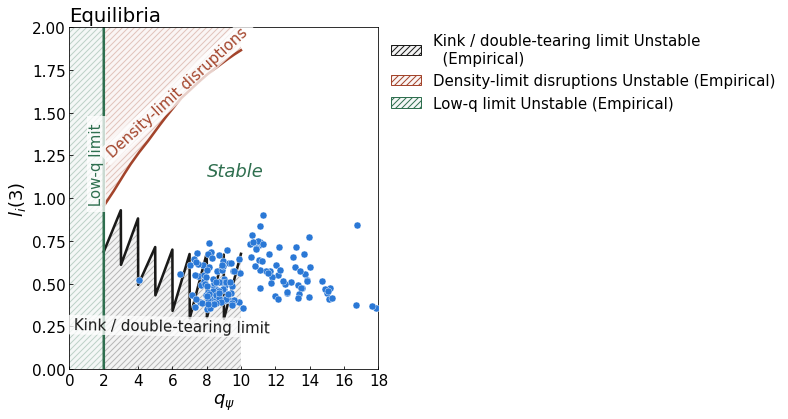

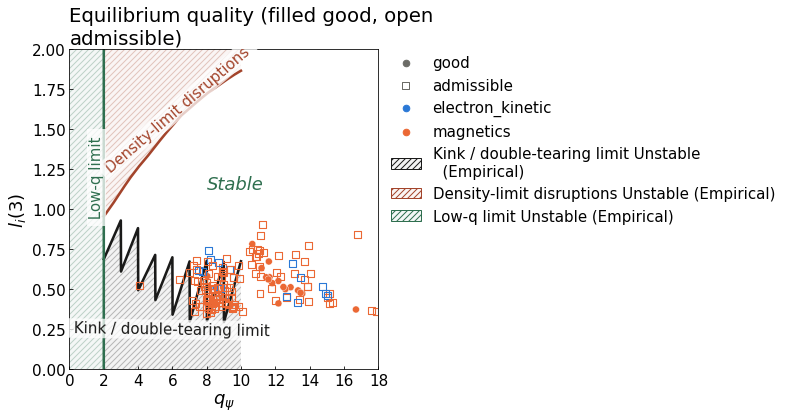

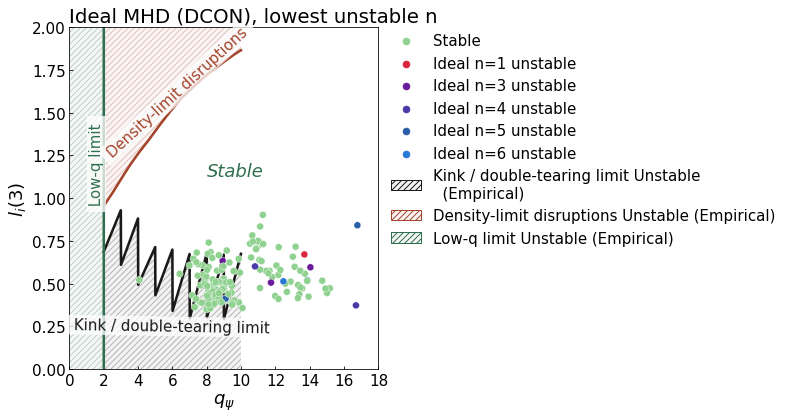

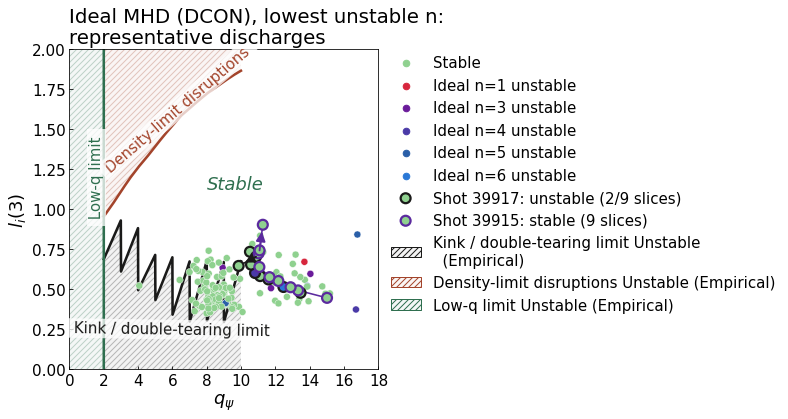

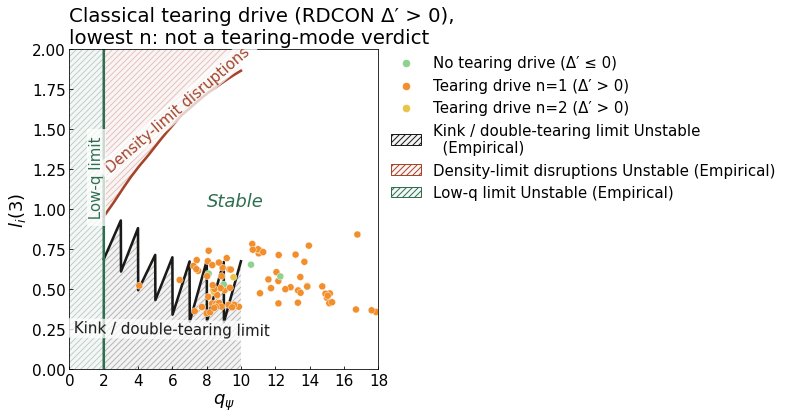

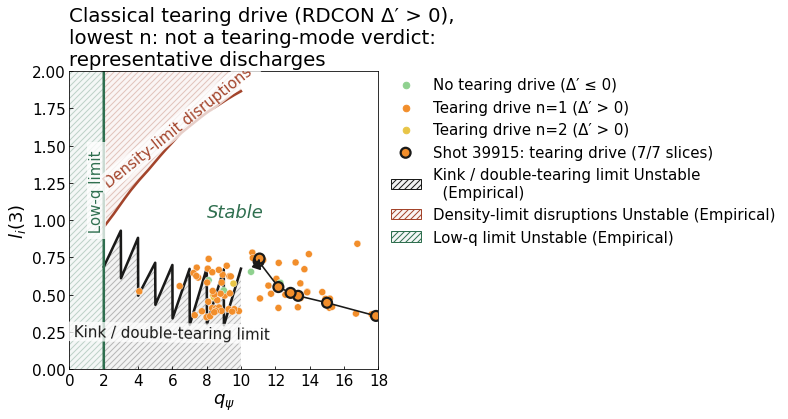

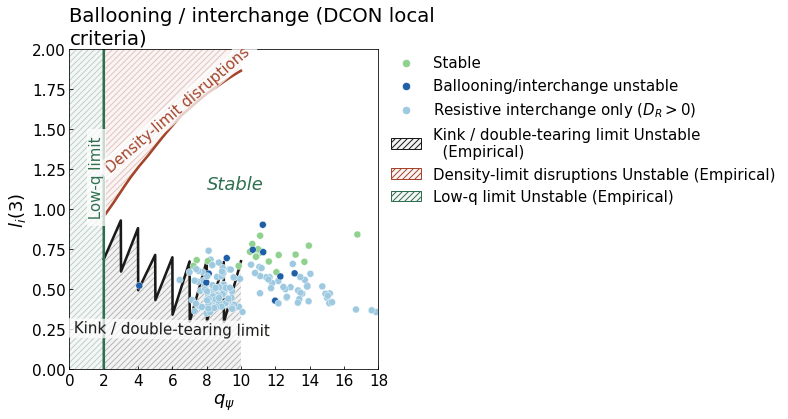

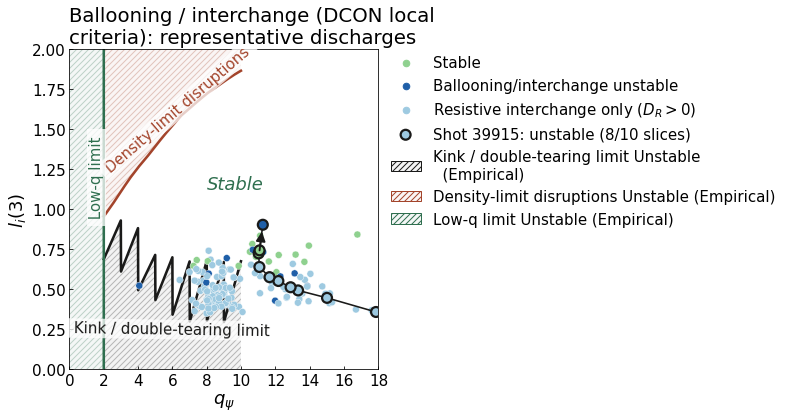

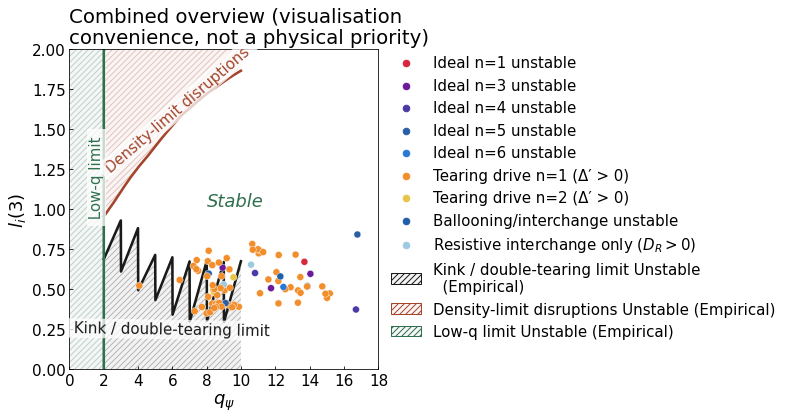

note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 54 of 139 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 54 of 139 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 37 of 80 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated:

In [ ]:
section("li_qa_wesson", x_range=(0.0, 18.0), y_range=(0.0, 2.0))

**Interpretation.**

- **Only 88 of the 150 states are inside the JET boundary's $q_\psi$ range** (2–10); the rest have $q_\psi$ up to 18, where JET's figure has no boundary.
- **Of those 88, 42 lie below the lower (kink/double-tearing) boundary and none above the upper (density-limit) one.** By JET's empirical picture, about half of the in-range VEST states would sit in the region where kink and double-tearing modes grew during JET's current rise.
- **But the VAFT stability verdicts do not follow the JET line:** below it, 18 states have an $n = 1$ tearing drive and 1 none; above it, 20 at $n = 1$, 3 at $n = 2$ and 1 none. The ideal-unstable states appear on both sides (one below, one inside) and the rest beyond $q_\psi = 10$. The JET boundary is an empirical, conventional-aspect-ratio result and does not transfer to VEST's $q_\psi$ and aspect ratio; it is shown as a reference, not as a VEST limit.
- The PPCF 2025 paper drew this plane with $q_a$; here the axis is the equilibrium's edge $q_\psi$, which is higher, so the states sit further right than in the paper's Fig. 9.

## Limit 7: the density limit, Hugill diagram

**What it is.** The Hugill diagram plots $\bar n_e R/B_T$ against $1/q_{cyl}$. The Greenwald limit
$\bar n_e \le I_p/(\pi a^2)$ is a line through the origin on it (with the area elongation $\kappa_a$, here the
population median), recast by VAFT onto these axes (**Derived** from the empirical Greenwald 1988/2002 limit; exceeded with
peaked profiles, so it is not a disruption criterion by itself). The Murakami line (Murakami et al. 1976: Ohmic, mostly
circular, conventional-aspect-ratio devices) is shown only as a **historical conventional-tokamak reference**, not as a
limit for a spherical tokamak; an ST-specific Hugill diagram is #1602.

**On this plane.** Only the 64 magnetics states with a Thomson line average can be placed: $\bar n_e$ is Lane D's
line average of the Thomson profile along the $z = 0$ chord inside the LCFS (a reconstructed line average, not an
interferometer measurement).

Hugill diagram: 64 of 150 states have both coordinates


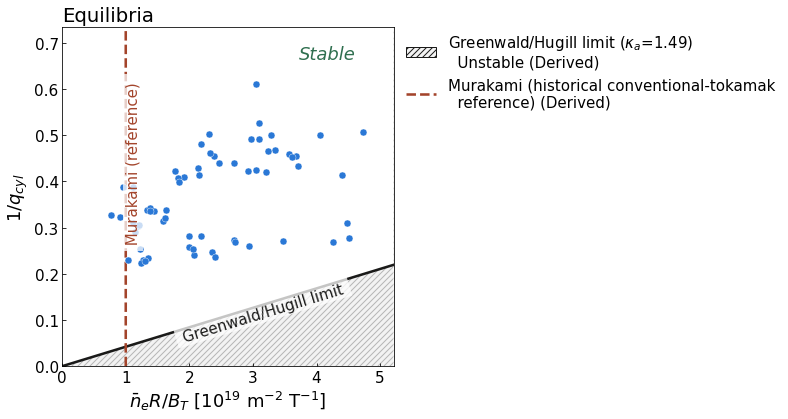

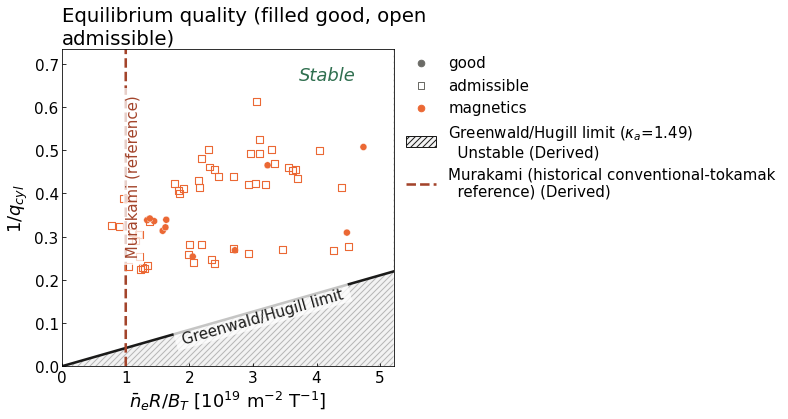

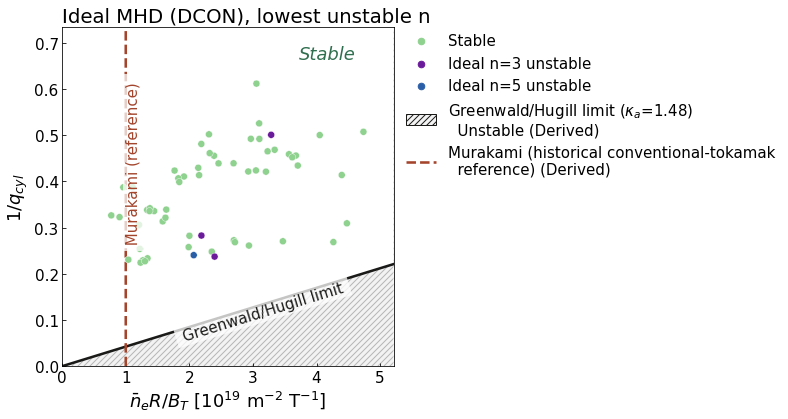

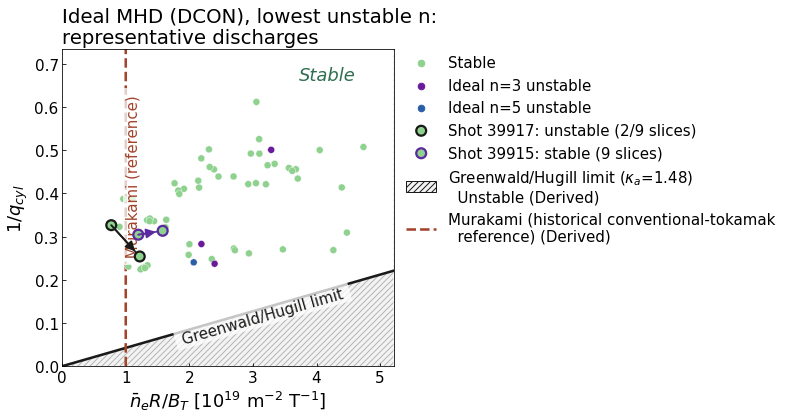

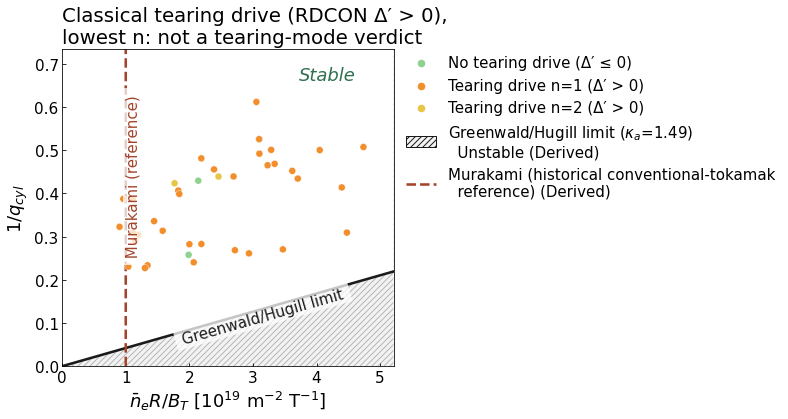

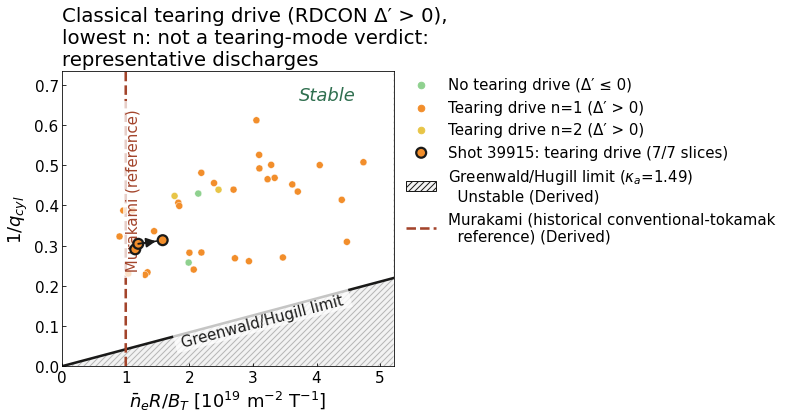

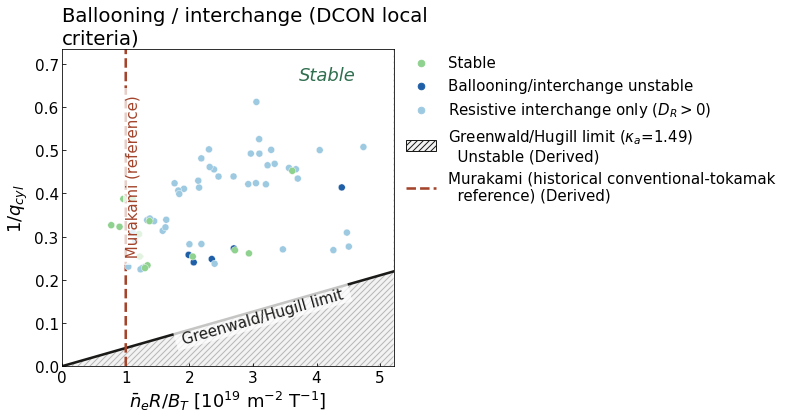

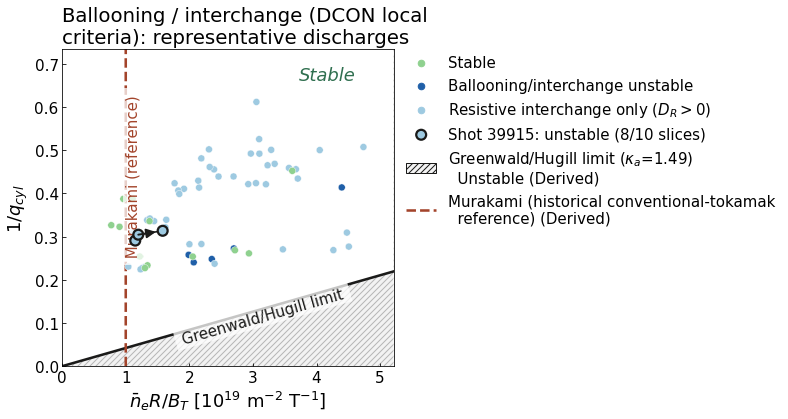

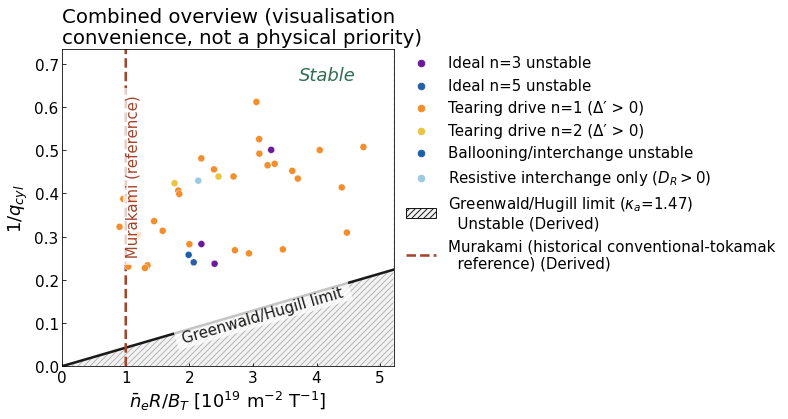

In [ ]:
section("hugill", x_range=(0.0, 1.1 * float(T["murakami_parameter"].max())),
        y_range=(0.0, 1.1 * float(T["inverse_cylindrical_q"].max())))

**Interpretation.**

- **All 64 states with a Thomson line average are below the Greenwald/Hugill line**: their distance to it is at most 0.69 of the limit (the same as $f_G \le 0.68$ in Limit 8). VEST's Tier A plasmas are not density-limited.
- **61 of the 64 are beyond the Murakami line, a historical conventional-tokamak reference** ($\bar n_e R/B_T > 1$). That limit is a 1976 fit to Ohmic, circular, stationary-fill devices at $B_T$ 0.6–7.5 T; VEST's low field puts its states far outside that range, and later devices also exceed it. It is shown for completeness.
- The stability classes do not order with density on this plane; the density planes include only the magnetics lineage at Thomson times, so they hold fewer of the classified states than the equilibrium planes.

## Limit 8: the Greenwald fraction against loss power

**What it is.** The same Greenwald limit as a fraction, $f_G = \bar n_e/n_G \le 1$ with $n_G = I_p/(\pi a^2)$
[$10^{20}\,\mathrm{m^{-3}}$, MA, m] (Greenwald 2002). Against the loss power it shows whether a state is
density-limited or simply under-fuelled. **Empirical.**

**On this plane.** $x = P_{loss} = P_{OH} - dW/dt$ [MW] (Lane D; radiation is not subtracted), $y = f_G$. The same
Thomson subset as Limit 7.

Greenwald fraction against loss power: 63 of 150 states have both coordinates


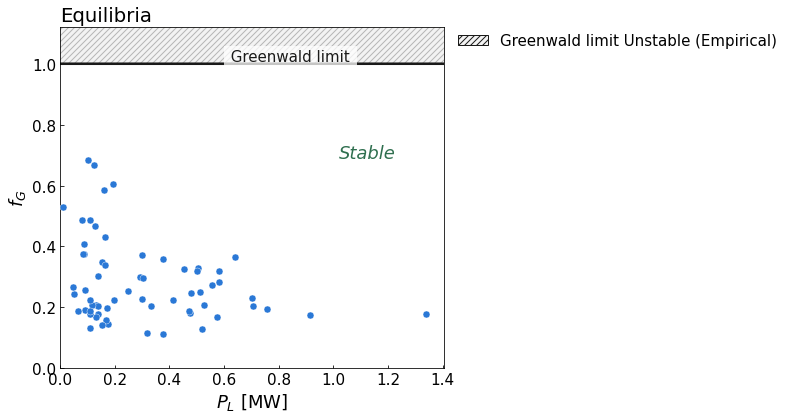

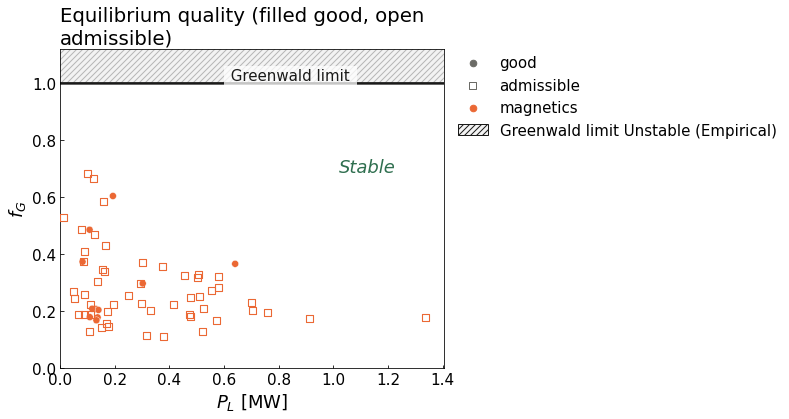

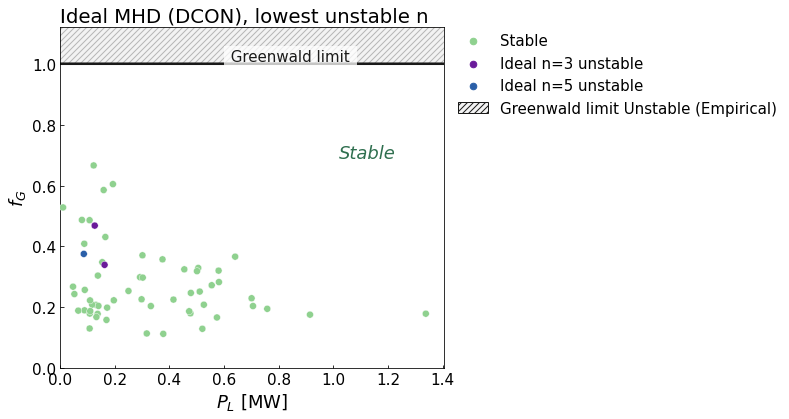

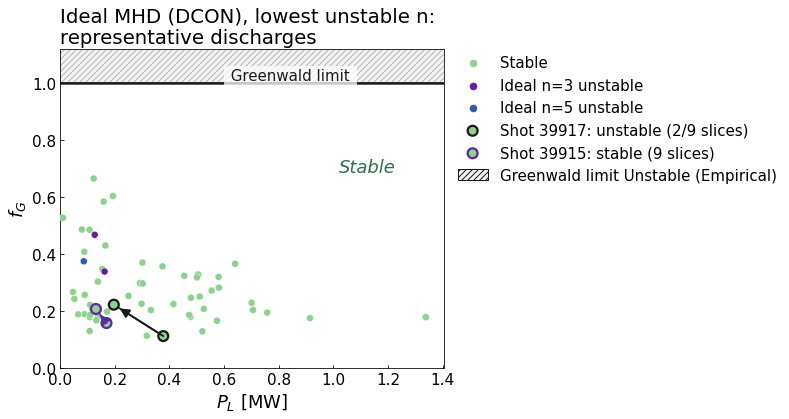

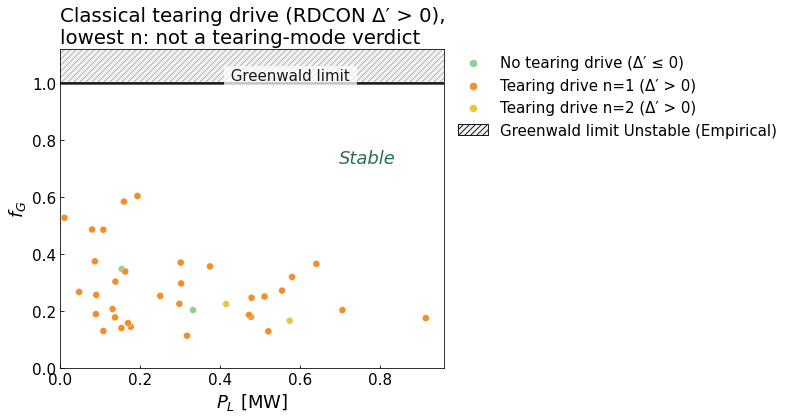

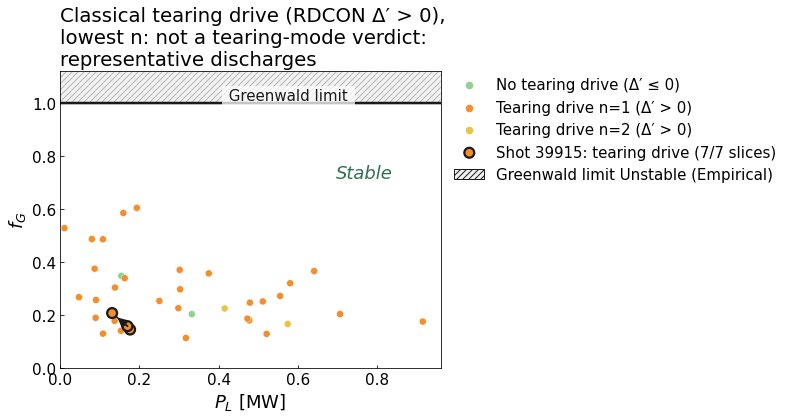

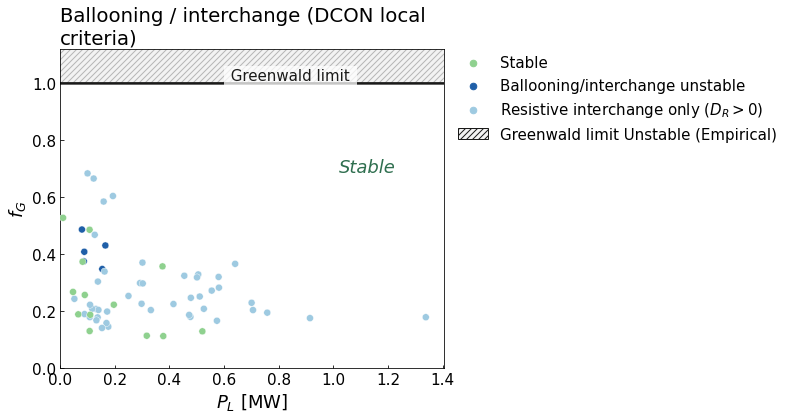

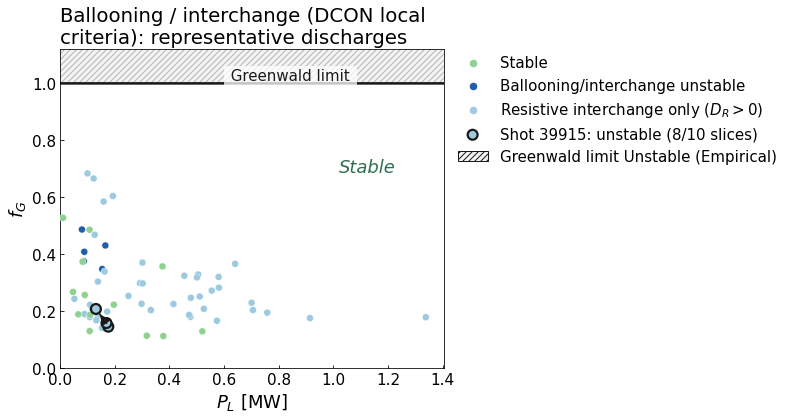

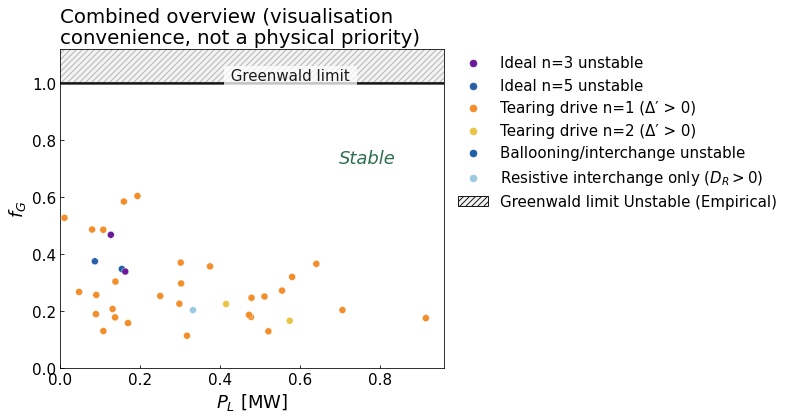

In [ ]:
section("greenwald_fraction_power", x_range=(0.0, None), y_range=(0.0, None))

**Interpretation.**

- $f_G$ is 0.11–0.68 (median 0.24) at $P_{loss}$ 0.01–1.3 MW: every state is well below the Greenwald limit, so density, not the limit, is what the discharges lack. This is the low-density, short-pulse operation the PPCF 2025 paper identified as the cause of VEST's low $\beta$: there is no flat-top in which to fuel the plasma.
- $f_G$ falls only weakly with $P_{loss}$ (Spearman ρ = −0.25 over 63 states), and the stability classes are spread over the plane: the three ideal-unstable states on this plane ($n = 3$ and 5, edge-driven) lie at ordinary $f_G$ (0.34–0.47).

## Limit 9: L–H transition access, $P_{loss}$ against $\bar n_e$

**What it is.** Not an MHD limit: the power above which an H-mode becomes accessible. Martin et al. (2008) is the
ITPA multi-machine scaling; Takizuka (2004) adds a low-aspect-ratio correction. Both are drawn at the population
median $B_T$, surface area, $I_p$, $a$ and $A$, with $Z_{eff} = 2$ as Lane D assumes. **Empirical.**

**On this plane.** $x = \bar n_e$ [$10^{20}\,\mathrm{m^{-3}}$], $y = P_{loss}$ [MW]. The hatched side is L-mode. VEST's
density and field lie below the fitted range of both scalings, so the lines are extrapolations; the stability colours
are kept so every section reads the same way.

Loss power against line-averaged density (L-H access): 63 of 150 states have both coordinates


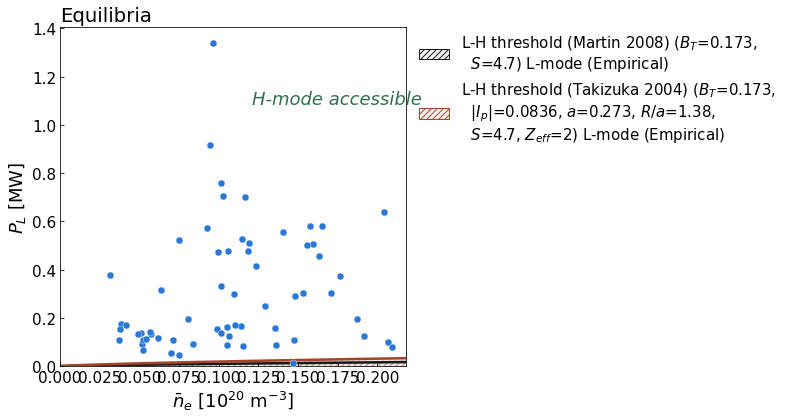

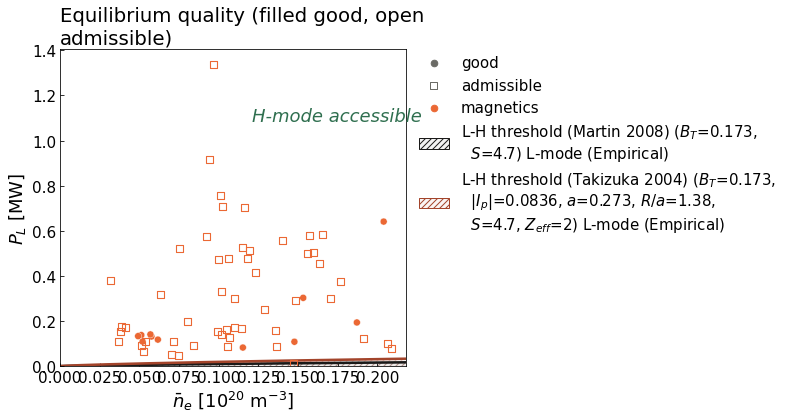

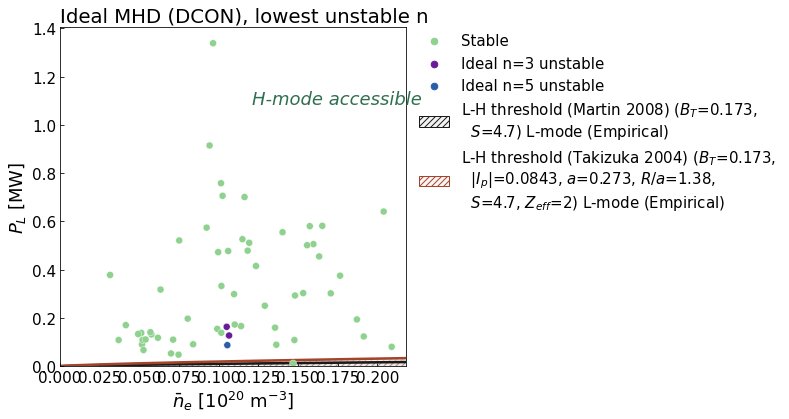

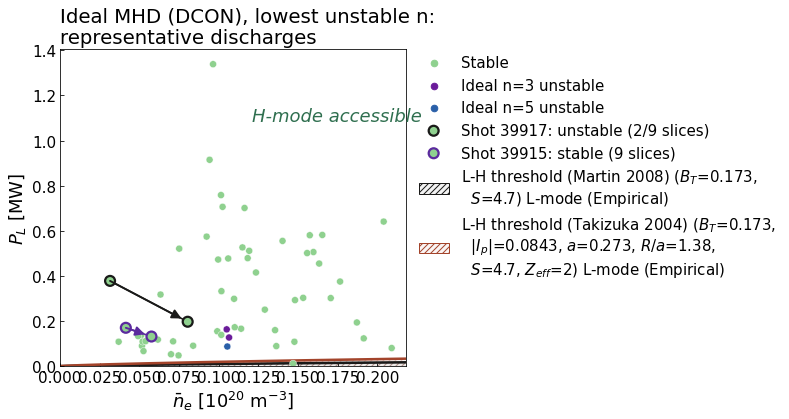

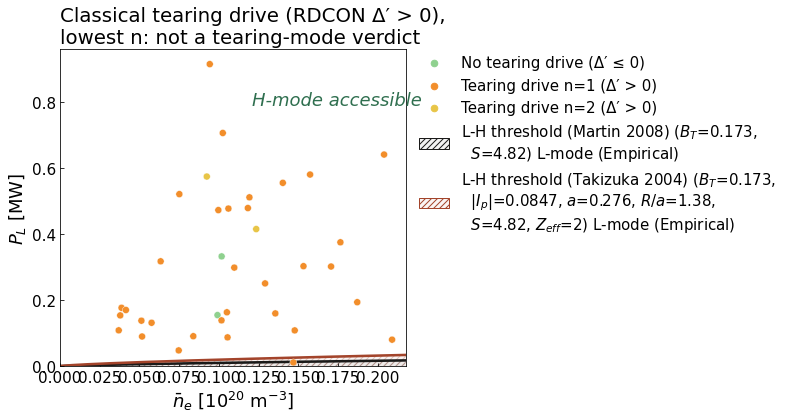

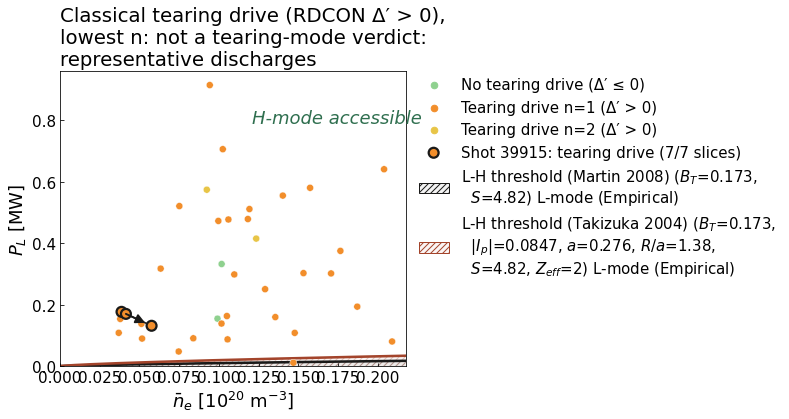

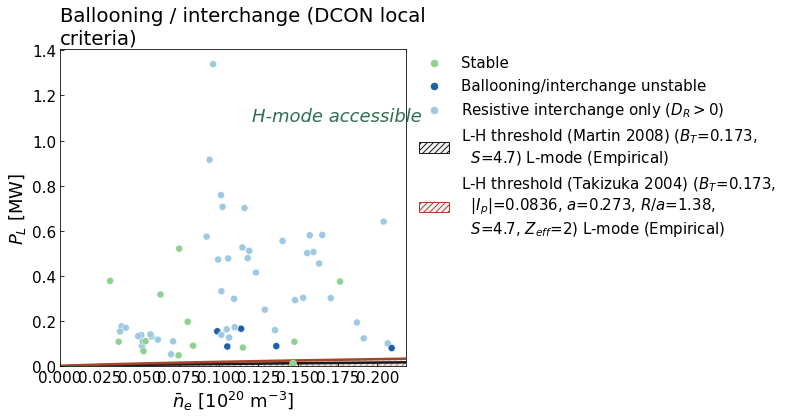

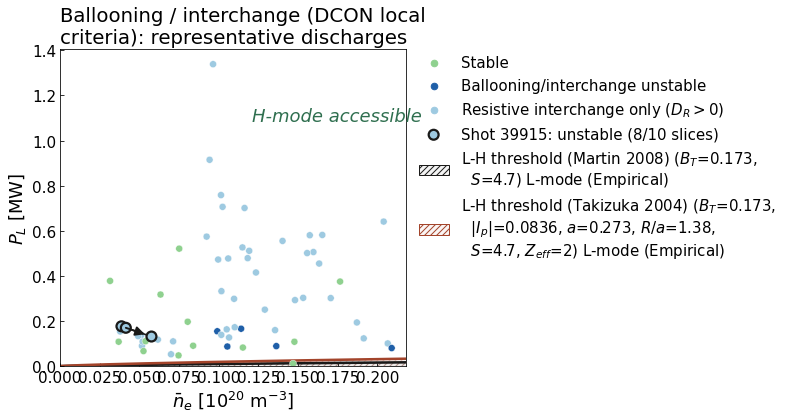

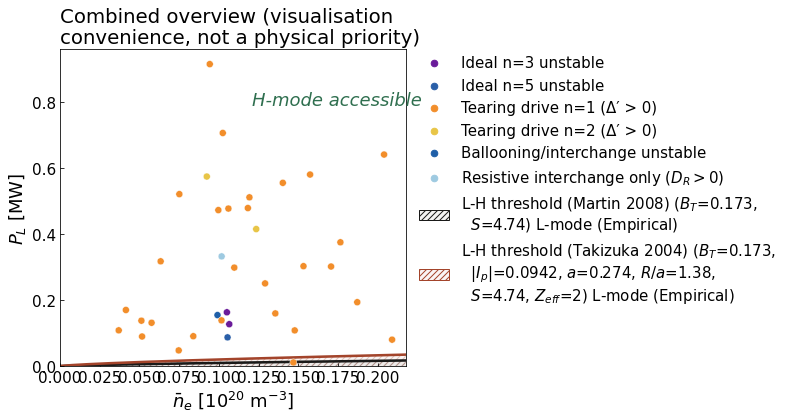

note: boundary 'takizuka_2004_lh' applies to: tokamak including spherical tokamaks


In [ ]:
section("lh_threshold", x_range=(0.0, None), y_range=(0.0, None), boundary_inputs={"effective_charge": 2.0})

**Interpretation.**

- **Formally, every state is above both thresholds**: $P_{loss}/P_{thr}$ is 1.1–(median) 21 for Martin 2008 and 0.7–(median) 10.5 for Takizuka 2004, with thresholds of only 4–49 kW at VEST's density and field.
- **This does not mean VEST plasmas are H-mode capable.** VEST's line-averaged density (0.03–0.21 × 10²⁰ m⁻³) and field are below the fitted range of both scalings, and both scalings are known to fail at low density, where the threshold rises again (the density minimum is not on this axis). The lines are extrapolations; the plane is shown so the L–H access question sits with the other limits, not as a prediction.
- The stability classes are not organised by $P_{loss}$ or $\bar n_e$.

## Summary

**What limits VEST's Tier A operation, by these criteria** (Lane N's atlas v2: DCON $n = 1$–6, RDCON $n = 1, 2$):

1. **No global hard limit is reached.** Every state clears the analytical external-kink limit ($q_*$ margin ≥ 1.32, $I_p \le 0.76\,I_{max}$), the Troyon limit ($\beta_N \le 0.88$ of it, with a pressure that the magnetics probably over-estimate) and the Greenwald limit ($f_G \le 0.68$).
2. **Ideal MHD instability is rare and edge-driven:** 129 resolution-robust states are stable and 10 unstable over $n = 1$–6 ($n = 1$: 1, $n = 3$: 3, $n = 4$: 2, $n = 5$: 3, $n = 6$: 1; 11 left out because a sign changes with resolution). Every unstable state is stable with the edge truncated at its lowest unstable $n$, so these are edge-sensitive, mostly medium-$n$ instabilities (39906 and 40324 keep an $n = 6$ instability with the truncated edge); they occur at high $q_*$ and low $I_N$ (medians 3.9 and 1.5) during the current ramp-down, away from the current limit, and can switch on and off between adjacent 1 ms slices.
3. **The classical tearing drive $\Delta' > 0$ (an outer-region criterion, not a tearing-mode verdict) is widespread** (73 of the 93 resolution-robust states at $n = 1$) and is not ordered by any of the nine planes, so it does not form an operating boundary here. It is also the most resolution-sensitive verdict: 57 states at $n = 1$ and 75 at $n = 2$ have no resolution-robust verdict (74 change it between mpsi 256 and 512, 1 has no run), and RDCON and STRIDE agree on only 87 of 150 at $n = 1$. Under #939, $\Delta' > 0$ is an outer-region drive, not a tearing verdict.
4. **Local criteria point at the core:** the GGJ resistive-interchange criterion fails in 124 of 150 states and ballooning in 12, with their worst surfaces near the axis (median $\psi_N$ 0.22 and 0.06), where VEST's EFIT has no internal constraint and the shear is weak. Ballooning appears as $l_i$ rises late in the discharge.
5. **Empirical boundaries from conventional tokamaks do not transfer:** the JET $l_i$–$q_\psi$ boundary, the Murakami limit and the L–H scalings are all extrapolated far outside their fitted ranges, and the stability verdicts do not follow them.

**Open:** the high-$\beta$ end needs the electron-kinetic pressure (Lane K's $R_W$); the $\Delta'$ verdict needs a resolution-converged and inner-layer treatment; the near-axis local criteria need equilibria with internal constraints.

## Provenance

Each layer's `MANIFEST.json` records its inputs (with sha256), the VAFT git sha and the command.

In [ ]:
import json
for manifest in sorted(ATLAS.glob("*/MANIFEST.json")):
    m = json.loads(manifest.read_text())
    print(f"{manifest.parent.name:10s} generated {m.get('generated_at')}  vaft {str(m.get('vaft_git'))[:9]}"
          f"  dirty={m.get('vaft_dirty')}  rows={m.get('rows')}")

confinement generated 2026-10-02T06:25:51.768479+00:00  vaft 48d5e1ae1  dirty=False  rows=133
lane_v     generated 2026-10-03T11:01:50+00:00  vaft 2dfbdd282  dirty=False  rows=150
v1         generated 2026-10-01T11:10:52+00:00  vaft 932a90358  dirty=False  rows={'state': 150, 'profiles': 405}
zeff       generated 2026-10-02T06:24:11+00:00  vaft None  dirty=None  rows=None
